In [110]:
from IPython.display import display, Image, HTML
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import seaborn as sns
import os,sys, re,sympy,pickle,io
import numpy as np
from matplotlib import patches
from mpi4py import MPI
from deap import tools, gp
import pandas as pd
from matplotlib import rc
import math
import re 

# Get the directory of the current notebook.
notebook_dir = os.getcwd()

# Compute the path to the directory containing `evostencils`.
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))

# Add this path to sys.path.
sys.path.append(parent_dir)

from evostencils.code_generation.hypre import ProgramGenerator as ProgramGeneratorHypre
from evostencils.code_generation.hyteg import ProgramGenerator as ProgramGeneratorHyteg
from evostencils.grammar import multigrid as initialization
from evostencils.ir import base, system
from evostencils.optimization.program import Optimizer
import evostencils.grammar.multigrid as mg_grammar

### I. Set Program generator

In [2]:
cwd = f'{os.getcwd()}'
eval_software = "hypre"

# I. Set up MPI
comm = MPI.COMM_WORLD
nprocs = comm.Get_size()
mpi_rank = comm.Get_rank()
if nprocs > 1:
    tmp = "processes"
else:
    tmp = "process"
if mpi_rank == 0:
    print(f"Running {nprocs} MPI {tmp}")

# II. problem specifications
problem_name = "2dpoisson"
flexmg_min_level = 0
flexmg_max_level = 4
cgs_level = 0
mg_grammar.optimize_cgs = False # optimises the tolerance and level of the coarse-grid solver
if mg_grammar.optimize_cgs:
    mg_grammar.cgs_tolerance = [1e-3, 1e-5, 1e-7, 1e-9] # set the options for the tolerance
    mg_grammar.cgs_level = [0, 1, 2] # set the options for the level
mg_grammar.optimize_cgc_scalingfactor = True # optimises the weights / scaling factors for coarse-grid correction (set to False with hyteg)
assert flexmg_min_level < flexmg_max_level
assert flexmg_min_level >= cgs_level
assert flexmg_max_level - flexmg_min_level < 5
if eval_software == "hyteg":
    assert not mg_grammar.optimize_cgc_scalingfactor
    program_generator = ProgramGeneratorHyteg(flexmg_min_level,flexmg_max_level , mpi_rank, cgs_level)
    mg_grammar.use_hypre = False
    mg_grammar.use_hyteg = True
elif eval_software == "hypre":
    program_generator = ProgramGeneratorHypre(flexmg_min_level, flexmg_max_level, mpi_rank)
    mg_grammar.use_hypre = True
    mg_grammar.use_hyteg = False

Running 1 MPI process


### II. Set Optimizer 


In [3]:

# Create directory for checkpoints and output data
#os.makedirs(f'{cwd}/{problem_name}')
# Path to directory for storing checkpoints
checkpoint_directory_path = f'{cwd}/{problem_name}/checkpoints_{mpi_rank}'


# III. Create optimizer object
optimizer = Optimizer(flexmg_min_level, flexmg_max_level, mpi_comm=comm, mpi_rank=mpi_rank, number_of_mpi_processes=nprocs,
                program_generator=program_generator, checkpoint_directory_path=checkpoint_directory_path)

# IV. optimization parameters
optimization_method = optimizer.NSGAII
mu_ = 4 # Population size
lambda_ = 4 # Number of offspring
generations = 4  # Number of generations
population_initialization_factor = 1  # Multiply mu_ by this factor to set the initial population size
generalization_interval = 150
crossover_probability = 0.7
mutation_probability = 1.0 - crossover_probability
node_replacement_probability = 0.1  # Probability to perform mutation by altering a single node in the tree
evaluation_samples = 1  # Number of evaluation samples

# V. Return values of the optimization
# program: program string representing the multigrid solver functions
# pops: Populations at the end of each optimization run on the respective subrange of the discretization hierarchy
# stats: Statistics structure (data structure provided by the DEAP framework)
# hofs: Hall-of-fames at the end of each optimization run on the respective subrange of the discretization hierarchy
get_pset = True
if get_pset:
    pset = optimizer.evolutionary_optimization(optimization_method=optimization_method,
                                                                use_random_search=False,
                                                                mu_=mu_, lambda_=lambda_,
                                                                population_initialization_factor=population_initialization_factor,
                                                                generations=generations,
                                                                generalization_interval=generalization_interval,
                                                                crossover_probability=crossover_probability,
                                                                mutation_probability=mutation_probability,
                                                                node_replacement_probability=node_replacement_probability,
                                                                levels_per_run=flexmg_max_level - flexmg_min_level,
                                                                evaluation_samples=evaluation_samples,
                                                                maximum_local_system_size=1,
                                                                continue_from_checkpoint=False,get_pset=True)

### III. Results

#### i. Combined Pareto Front

In [5]:
global_hof = tools.ParetoFront()
def plot_pareto_front(optimizer, base_path='./', number_of_experiments=1, ref_solvers=None, relative_residual_norm =1e-8, scatter_color = ['blue', 'black'], line_color = ['red', 'green']):
    fig, ax = plt.subplots()
    # check if base_path is not a list, if not, convert it to a list
    if not isinstance(base_path, list):
        base_path_list = [base_path]
    else:
        base_path_list = base_path
    for index, base_path in enumerate(base_path_list):
        hofs = []
        front = []
        for i in range(number_of_experiments):
            pop = optimizer.load_data_structure(f'{base_path}/data_{i}/pop_0.p')
            hof = tools.ParetoFront()
            hof.update(pop)
            hofs.append(hof)
            front += [(ind.fitness.values[0], ind.fitness.values[1], 1) for ind in hof]
            global_hof.update(pop)

        global_front = [(ind.fitness.values[0], ind.fitness.values[1], 'red') for ind in global_hof]
        
        # create a dataframe with columns 'Solver', 'Convergence_Factor', 'Execution_Time'
        # Loop through global_hof and add the data to the dataframe

        results = []
        for i,ind in enumerate(global_hof):
            convergence_factor = ind.fitness.values[0]
            execution_time_per_iteration = ind.fitness.values[1]
            number_of_iterations = math.ceil(math.log(relative_residual_norm, convergence_factor))
            execution_time =  number_of_iterations * execution_time_per_iteration
            solver = f'individual_{i}'
            results.append({'Solver': solver, 
                            'Convergence_Factor': convergence_factor, 
                            'Number_of_Iterations': number_of_iterations,
                            'Execution_Time_per_Iteration(ms)': execution_time_per_iteration, 
                            'Execution_Time(ms)': execution_time})
        # add the reference solvers to the dataframe
        if ref_solvers is not None:
            for i,solver in enumerate(ref_solvers):
                results.append({'Solver': solver[2], 
                                'Convergence_Factor': solver[0], 
                                'Number_of_Iterations': math.ceil(math.log(relative_residual_norm, solver[0])),
                                'Execution_Time_per_Iteration(ms)': solver[1], 
                                'Execution_Time(ms)': math.ceil(math.log(relative_residual_norm, solver[0])) * solver[1]})
        
        
        df = pd.DataFrame(results)
        # sort the dataframe by 'Execution_Time' min to max
        df = df.sort_values(by='Execution_Time(ms)')    
        # display the full dataframe
        pd.set_option('display.max_rows', None)


        columns = ['Convergence Factor', 'Execution Time per Iteration (ms)', 'Experiment']
        df1 = pd.DataFrame(front, columns=columns)
        df2 = pd.DataFrame(global_front, columns=columns)
        rc('text', usetex=False)
        sns.set_context("paper")
        sns.set_style('ticks', {'font.family': 'serif', 'font.serif': 'Times New Roman'})

        sns.scatterplot(x=columns[0], y=columns[1], style=columns[2], hue=columns[2],
                        data=df1, legend=False, ax=ax, alpha=0.35, color=scatter_color[index])
        sns.lineplot(x=columns[0], y=columns[1], color=line_color[index],
                    data=df2, legend=False,
                    ax=ax)
        if ref_solvers is not None:
            for solver in ref_solvers:
                ax.plot(solver[0], solver[1],marker='x', markersize=4, color=line_color[index])
                ax.text(solver[0], solver[1], solver[2])
        display(df)
    plt.tight_layout()
    plt.show()
    

,Solver,Convergence_Factor,Number_of_Iterations,Execution_Time_per_Iteration(ms),Execution_Time(ms)
45,individual_45,0.105125,12,15.881667,190.58000
41,individual_41,0.075039,10,19.332100,193.32100
50,individual_50,0.179132,15,12.899733,193.49600
44,individual_44,0.094571,11,17.742091,195.16300
43,individual_43,0.085155,11,17.843364,196.27700
33,individual_33,0.039480,8,24.540250,196.32200
53,individual_53,0.195479,16,12.315188,197.04300
48,individual_48,0.154190,14,14.130714,197.83000
52,individual_52,0.195058,16,12.370125,197.92200
40,individual_40,0.073585,10,19.821100,198.21100


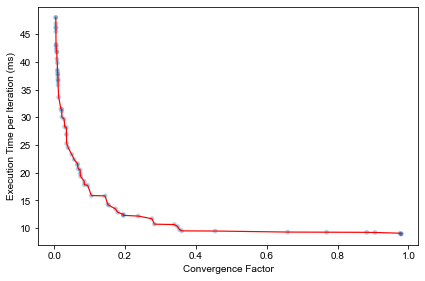

In [6]:

# ref_solvers is a list of tuples, where each tuple contains the convergence factor, execution time per iteration (ms), and the name of the solver
ref_solvers = []


#ref_solvers.append((0.126542, 0.191418*1000/8,'V(1,1)'))
#ref_solvers.append((0.002611, 0.126639*1000/3,'F(1,1)'))


folder_path_1 = "/Users/dinesh/Documents/Work/evostencils_new/evostencils/3dpoisson_withrelaxorder"
folder_path_2 = "/Users/dinesh/Documents/Work/evostencils_new/evostencils/3dpoisson"
folder_path = [folder_path_1, folder_path_2]
number_of_experiments = 1
relative_residual_norm = 1e-8/1.294290e+03
plot_pareto_front(optimizer, folder_path_2, number_of_experiments, ref_solvers, relative_residual_norm)

In [7]:
def getmgcycle(index):
    individual = global_hof[index]
    expression, _  = gp.compile(individual, pset)
    return program_generator.generate_cycle_function(expression)
def viz_cycle(list_hof_indices, oamgargs=[]):
        
        # create a figure with a grid of subplots
        n_subplots = len(list_hof_indices)
        fig, axs = plt.subplots(n_subplots, 1, figsize=(40, n_subplots*10))

        # set text size
        plt.rcParams.update({'font.size': 30})
        
        for j,index in enumerate(list_hof_indices):
            # get the index of the subplot
            if n_subplots == 1:
                ax = axs
            else:
                ax = axs[j]

            oamgargs.append(getmgcycle(index))
            mg_cycle_list = oamgargs[-1].split("/")
            print(f'Individual_{list_hof_indices[j]}, MG Cycle: {mg_cycle_list}')
            # second entry is a list to specify inter-grid transfer operators
            inter_grid_transfer_operators = [int(i) for i in mg_cycle_list[1].split(",")]
            # third entry is a list to specify smoother types
            smoother_types = [int(i) for i in mg_cycle_list[2].split(",")]
            # fifth entry is a list to specify smoother relaxation factors
            smoother_relaxation_factors = [round(float(i),2) for i in mg_cycle_list[5].split(",")]
            outer_relaxation_factors = [round(float(i),2) for i in mg_cycle_list[4].split(",")]
            cgc_relaxation_factors = [round(float(i),2) for i in mg_cycle_list[6].split(",")]
            #relax_order = [int(i) for i in mg_cycle_list[4].split(",")]
            n_nodes = len(smoother_types)
            # Create a multigrid graph
            import networkx as nx
            G = nx.DiGraph()

            # construct dictionary mapping smoother types to node colors
            smoother_colors = {0: '#ADD8E6', 3:'#FF6666', 4:'#90EE90',9: 'black', 18:'darkblue',13:'darkred',14:'darkgreen',-1: 'white'}
            smoother_names = {0: 'Jacobi',3:'GSFwd',4:'GSBwd', 9: 'CGS', 18: 'l1Jac', 13: 'l1GSFwd',14:'l1GSBwd',-1: 'NoSmoother'}
            linewidth_dict = {0:1.5,1:5}
            edgecolor_dict = {0:'black',1:'red'}
            # construct a list of coordinate tuples for each node
            coord_nodes = []
            node_colors =[]
            line_width = []
            edge_colors = []
            y=0
            x=0
            n_nodes = len(inter_grid_transfer_operators)+1
            for i in range(n_nodes):
                coord_nodes.append((x,y))
                node_colors.append(smoother_colors[smoother_types[i]])
                #line_width.append(linewidth_dict[relax_order[i]])
                #edge_colors.append(edgecolor_dict[relax_order[i]])
                if i<n_nodes-1:
                    y+=inter_grid_transfer_operators[i]
                    if inter_grid_transfer_operators[i] == 0:
                        x+=2
                    else:
                        x+=1
            
            G.add_nodes_from(coord_nodes) # add nodes to graph
            # construct list of edges, each edge is a tuple of two coordinate tuples, connecting consecutive nodes in the coord_nodes list
            edges = []
            for i in range(len(coord_nodes)-1):
                edges.append((coord_nodes[i],coord_nodes[i+1]))
            G.add_edges_from(edges) # add edges to graph


            # Draw nodes
            # create a pos dictionary mapping each node to its coordinate tuple
            pos = {}
            for i in range(len(coord_nodes)):
                pos[coord_nodes[i]] = coord_nodes[i]




            nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2300, node_color=node_colors, edgecolors='black', linewidths=1.5)

            # Draw edges
            nx.draw_networkx_edges(G, pos, ax=ax, width=1, edge_color='lightgray', arrowsize=20)

            # Annotate nodes with smoother information
            for i,relax_factor in enumerate(smoother_relaxation_factors):
                ax.annotate(relax_factor, coord_nodes[i], fontsize=25, ha='center', va='center', color='black')
            
            # annotate outer relaxation factors just outside the nodes
            for i,relax_factor in enumerate(outer_relaxation_factors):
                if relax_factor != 1.0 and relax_factor != 0.0:
                    ax.annotate(relax_factor, (coord_nodes[i][0]+0.1,coord_nodes[i][1]+0.3), fontsize=25, ha='center', va='center', color='black')
            # Annotate edges with cgc relaxation factor
                
            for i,relax_factor in enumerate(cgc_relaxation_factors):
                if inter_grid_transfer_operators[i] == 1:
                    ax.annotate(relax_factor, ((coord_nodes[i][0]+coord_nodes[i+1][0])/2,(coord_nodes[i][1]+coord_nodes[i+1][1])/2), fontsize=25, ha='center', va='center', color='black')
            # remove axis
            ax.axis('off')
            
            # add legends for node colors with edge colors
            handles = []
            labels = []
            for smoother in smoother_names:
                handles.append(patches.Patch(color=smoother_colors[smoother], label=smoother))
                labels.append(smoother_names[smoother])
            legends = plt.legend(handles, labels, title="Smoother Types", loc='lower left')
            for legend in legends.legendHandles:
                legend.set_edgecolor('black')
            
            ax.set_title(f'Individual_{list_hof_indices[j]}',fontsize=40)

        # Show the plot
        plt.tight_layout()
        plt.savefig('g3phof.pdf', format='pdf', bbox_inches='tight',dpi = 300)
        plt.show()

In [31]:
# create a list of indices of individuals in the global hall of fame
list_length = len(global_hof)
list_hof_indices = [i for i in range(list_length)]
# visualize the multigrid cycles of the individuals in the list_hof_indices
amgargs = []
viz_cycle(list_hof_indices,amgargs)


Individual_0, MG Cycle: ['32', '0,0,0,0,0,0,0,-1,-1,-1,1,0,1,-1,-1,0,0,0,0,0,-1,1,1,1,1,0,-1,0,1,0,0', '13,14,4,13,13,14,4,13,-1,-1,13,3,18,4,14,13,14,18,14,14,13,9,-1,-1,18,13,14,4,14,3,14,14', '1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1', '1.0,1.0,1.8,1.0,1.0,1.0,0.8999999999999999,1.0,0,0,1.0,1.8499999999999999,1.0,1.35,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,0,0,1.0,1.0,1.0,1.75,1.0,0.8999999999999999,1.0,1.0', '1.0,1.0,1.5999999999999999,1.0,1.0,1.0,1.5999999999999999,1.0,0,0,1.0,1.5999999999999999,1.0,1.65,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,0,0,1.0,1.0,1.0,1.45,1.0,1.7,1.0,1.0', '0,0,0,0,0,0,0,1,1,1,1.65,0,0.7999999999999999,1,1,0,0,0,0,0,1,1.05,0.6,1.8499999999999999,0.95,0,1,0,0.9999999999999999,0,0']
Individual_1, MG Cycle: ['32', '0,0,0,0,0,0,0,-1,-1,-1,1,0,1,-1,-1,0,0,0,0,0,-1,1,1,1,1,0,-1,0,1,0,0', '13,14,4,13,13,14,4,13,-1,-1,13,3,18,4,14,13,14,18,14,14,14,9,-1,-1,18,13,14,4,14,3,14,14', '1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1', '1.0,1.0,1.8,

/var/folders/s9/y5h9gb1n7td480vs2n92vcnw0000gn/T/ipykernel_7174/1176098020.py:83: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, ax=ax, width=1, edge_color='lightgray', arrowsize=20)


Individual_55, MG Cycle: ['10', '-1,-1,-1,-1,1,1,1,1,0', '-1,18,18,18,9,-1,0,-1,3,0', '0,1,1,1,1,0,1,0,1,1', '0,1.0,1.0,1.0,1,0,1.65,0,0.8999999999999999,0.4', '0,1.0,1.0,1.0,1,0,0.6499999999999999,0,1.0999999999999999,0.44999999999999996', '1,1,1,1,1.2,0.7499999999999999,1.5999999999999999,0.9999999999999999,0']
Individual_56, MG Cycle: ['10', '-1,-1,-1,-1,1,1,1,1,0', '-1,18,18,18,9,-1,-1,-1,0,14', '0,1,1,1,1,0,0,0,1,1', '0,1.0,1.0,1.0,1,0,0,0,0.44999999999999996,1.0', '0,1.0,1.0,1.0,1,0,0,0,0.35,1.0', '1,1,1,1,0.7999999999999999,0.6,1.5999999999999999,0.9999999999999999,0']
Individual_57, MG Cycle: ['9', '-1,-1,-1,-1,1,1,1,1', '-1,18,-1,18,9,-1,0,-1,3', '0,1,0,1,1,0,1,0,1', '0,1.0,0,1.0,1,0,1.65,0,0.8999999999999999', '0,1.0,0,1.0,1,0,0.6499999999999999,0,1.0999999999999999', '1,1,1,1,1.2,0.7499999999999999,1.5999999999999999,0.95']
Individual_58, MG Cycle: ['9', '-1,-1,-1,-1,1,1,1,1', '-1,18,-1,18,9,-1,0,-1,14', '0,1,0,1,1,0,1,0,1', '0,1.0,0,1.0,1,0,1.65,0,1.0', '0,1.0,0,1.0,1,0,0.6

KeyboardInterrupt: 

## Generate job scripts

In [ ]:
# create a shell script to run the multigrid cycles
with open(f"job_g3phof.sh", 'w', newline='\n') as f:   
    print(f'#!/bin/bash',file=f) 

    print(f'#SBATCH -N 1',file=f)
    print(f'#SBATCH --ntasks-per-socket=8',file=f)
    print(f'#SBATCH -t 1:00:00',file=f)
    print(f'#SBATCH -p pbatch',file=f)
    print(f'#SBATCH -A paratime',file=f)
    print(f'#SBATCH -o out_g3phof',file=f)

    for amgarg in amgargs:
        print(f'srun -n 8 ./ij -solver 0 -P 2 2 2 -n 100 100 100 -c 0.001 1 1 -x0rand -rhszero -pout 0 -amgusrinputs 1 {amgarg}',file=f)


In [24]:
tags = ['GSFwd_CF','GSBwd_CF','SymGS_CF','Jac_CF','l1Jac_CF','l1GSFwd_CF','l1GSBwd_CF','Syml1GS_CF','GSFwdBwd(1,2)_CF','l1GSFwdBwd(2,1)_CF']
tags = ['GSFwd','GSBwd','SymGS','Jac','CFJac','Chebyo2','l1Jac','l1GSFwd','l1GSBwd','Syml1GS','GSFwdBwd(1,2)','l1GSFwdBwd(2,1)']
cycle_args = ['-rlx_down 3 -rlx_up 3 -w 1.1 -ow 0.9',
              '-rlx_down 4 -rlx_up 4 -w 1.1 -ow 0.9',
              '-rlx_down 6 -rlx_up 6 -ow -16',
              '-rlx_down 0 -rlx_up 0 -w 0 -ow -16',
              '-rlx_down 17 -rlx_up 17',
              '-rlx_down 16 -rlx_up 16 -cheby_order 2',
              '-rlx_down 18 -rlx_up 18',
              '-rlx_down 13 -rlx_up 13',
              '-rlx_down 14 -rlx_up 14',
              '-rlx_down 89 -rlx_up 89',
              '-rlx_down 3 -rlx_up 4  -w 1.1 -ow 0.9 -ns_down 1 -ns_up 2',
              '-rlx_down 13 -rlx_up 14 -ns_down 2 -ns_up 1']

assert len(tags) == len(cycle_args)

for i,tag in enumerate(tags):
    with open(f"norelaxorder/var_anisotropy/job_{tag}.sh", 'w', newline='\n') as f: 
        print(f'#!/bin/bash',file=f) 

        print(f'#SBATCH -N 1',file=f)
        print(f'#SBATCH --ntasks-per-socket=8',file=f)
        print(f'#SBATCH -t 2:00:00',file=f)
        print(f'#SBATCH -p pbatch',file=f)
        print(f'#SBATCH -A paratime',file=f)
        print(f'#SBATCH -o out_{tag}_varanisotropy',file=f)

        print(f'cd /g/g91/parthasa/hypre_original/hypre/src/test',file=f)

        cx_list = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
        cy_list = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
        cz_list = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
        for cx in cx_list:
            for cy in cy_list:
                for cz in cz_list:
                    print(f'srun -n 8 ./ij -solver 0 -P 2 2 2 -n 100 100 100 -c {cx} {cy} {cz} -x0rand -rhszero {cycle_args[i]}',file=f)



In [14]:

os.makedirs(f'weakscaling',exist_ok=True)
with open(f"weakscaling/job_relaxtypesbest_weakscaling.sh", 'w', newline='\n') as f:   

    print(f'#!/bin/bash',file=f) 

    print(f'#SBATCH -N 500',file=f)
    print(f'#SBATCH --ntasks-per-socket=8',file=f)
    print(f'#SBATCH -t 0:30:00',file=f)
    print(f'#SBATCH -p pbatch',file=f)
    print(f'#SBATCH -A paratime',file=f)
    print(f'#SBATCH -o out_relaxtypesbest_weakscaling',file=f)

    num_sockets_list = [1,8,27,64,125,216,343,512,729,1000]
    for i,num_sockets in enumerate(num_sockets_list):
        num_procs = num_sockets * 8
        procs_dim = int(math.ceil(num_procs**(1/3)))
        N = 50*procs_dim
        num_nodes = math.ceil(num_sockets/2)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 3 -rlx_up 3 -c 0.001 1 1 -w 1.1 -ow 0.9',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 4 -rlx_up 4 -c 0.001 1 1 -w 1.1 -ow 0.9',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 6 -rlx_up 6 -c 0.001 1 1 -ow -16',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 0 -rlx_up 0 -c 0.001 1 1 -w 0 -ow -16',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 17 -rlx_up 17 -c 0.001 1 1',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 16 -rlx_up 16 -cheby_order 2 -c 0.001 1 1',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 18 -rlx_up 18 -c 0.001 1 1',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 13 -rlx_up 13 -c 0.001 1 1',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 14 -rlx_up 14 -c 0.001 1 1',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 89 -rlx_up 89 -c 0.001 1 1',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 3 -rlx_up 4 -c 0.001 1 1 -w 1.1 -ow 0.9 -ns_down 1 -ns_up 2',file=f)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -pout 0 -x0rand -rhszero -rlx_down 13 -rlx_up 14 -c 0.001 1 1 -ns_down 2 -ns_up 1',file=f)


        


In [12]:
hof_indices = [23, 33, 34, 35, 50]
for hof_index in hof_indices:
    os.makedirs(f'weakscaling',exist_ok=True)
    with open(f"weakscaling/job_g3p_{hof_index}_weakscaling.sh", 'w', newline='\n') as f:   

        print(f'#!/bin/bash',file=f) 

        print(f'#SBATCH -N 500',file=f)
        print(f'#SBATCH --ntasks-per-socket=8',file=f)
        print(f'#SBATCH -t 0:30:00',file=f)
        print(f'#SBATCH -p pbatch',file=f)
        print(f'#SBATCH -A paratime',file=f)
        print(f'#SBATCH -o out_g3p_{hof_index}_weakscaling',file=f)

        num_sockets_list = [1,8,27,64,125,216,343,512,729,1000]
        for i,num_sockets in enumerate(num_sockets_list):
            
            num_procs = num_sockets * 8
            procs_dim = int(math.ceil(num_procs**(1/3)))
            N = 50*procs_dim
            num_nodes = math.ceil(num_sockets/2)

            # III. Create optimizer object
            flexmg_max_level = program_generator.max_level = num_levels_ref[i] - 1
            flexmg_min_level = program_generator.min_level = flexmg_max_level - 4
            optimizer = Optimizer(flexmg_min_level, flexmg_max_level, mpi_comm=comm, mpi_rank=mpi_rank, number_of_mpi_processes=nprocs,
                            program_generator=program_generator, checkpoint_directory_path=checkpoint_directory_path)

            # IV. optimization parameters
            optimization_method = optimizer.NSGAII
            mu_ = 4 # Population size
            lambda_ = 4 # Number of offspring
            generations = 4  # Number of generations
            population_initialization_factor = 1  # Multiply mu_ by this factor to set the initial population size
            generalization_interval = 150
            crossover_probability = 0.7
            mutation_probability = 1.0 - crossover_probability
            node_replacement_probability = 0.1  # Probability to perform mutation by altering a single node in the tree
            evaluation_samples = 1  # Number of evaluation samples

            # V. Return values of the optimization
            # program: program string representing the multigrid solver functions
            # pops: Populations at the end of each optimization run on the respective subrange of the discretization hierarchy
            # stats: Statistics structure (data structure provided by the DEAP framework)
            # hofs: Hall-of-fames at the end of each optimization run on the respective subrange of the discretization hierarchy
            get_pset = True
            if get_pset:
                pset = optimizer.evolutionary_optimization(optimization_method=optimization_method,
                                                                            use_random_search=False,
                                                                            mu_=mu_, lambda_=lambda_,
                                                                            population_initialization_factor=population_initialization_factor,
                                                                            generations=generations,
                                                                            generalization_interval=generalization_interval,
                                                                            crossover_probability=crossover_probability,
                                                                            mutation_probability=mutation_probability,
                                                                            node_replacement_probability=node_replacement_probability,
                                                                            levels_per_run=flexmg_max_level - flexmg_min_level,
                                                                            evaluation_samples=evaluation_samples,
                                                                            maximum_local_system_size=1,
                                                                            continue_from_checkpoint=False,get_pset=True)
            expression, _  = gp.compile(global_hof[hof_index], pset)
            amgarg = program_generator.generate_cycle_function(expression)
            print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -c 0.001 1 1 -pout 0 -x0rand -rhszero -amgusrinputs 1 {amgarg}',file=f)


NameError: name 'amgarg' is not defined

In [74]:
os.makedirs(f'weakscaling',exist_ok=True)
with open(f"weakscaling/job_l1GSFwdBwd(2,1)_weakscaling.sh", 'w', newline='\n') as f:   
    print(f'#!/bin/bash',file=f) 

    print(f'#SBATCH -N 500',file=f)
    print(f'#SBATCH --ntasks-per-socket=8',file=f)
    print(f'#SBATCH -t 0:30:00',file=f)
    print(f'#SBATCH -p pbatch',file=f)
    print(f'#SBATCH -A paratime',file=f)
    print(f'#SBATCH -o out_l1GSFwdBwd(2,1)_weakscaling',file=f)

    num_sockets_list = [1,8,27,64,125,216,343,512,729,1000]
    for num_sockets in num_sockets_list:
        num_procs = num_sockets * 8
        procs_dim = int(math.ceil(num_procs**(1/3)))
        N = 50*procs_dim
        num_nodes = math.ceil(num_sockets/2)
        print(f'srun -N {num_nodes} -n {num_procs} ./ij -solver 0 -P {procs_dim} {procs_dim} {procs_dim} -n {N} {N} {N} -x0rand -rhszero -rlx_down 13 -rlx_up 14 -c 0.001 1 1 -ns_down 2 -ns_up 1',file=f)


In [11]:
hof_indices = [22, 27, 28, 31, 33, 36]
os.makedirs(f'withrelaxorder', exist_ok=True)
os.makedirs(f'withrelaxorder/var_anisotropy', exist_ok=True)
for hof_index in hof_indices:
    with open(f"withrelaxorder/var_anisotropy/job_g3p_{hof_index}.sh", 'w', newline='\n') as f:   
        print(f'#!/bin/bash',file=f) 

        print(f'#SBATCH -N 1',file=f)
        print(f'#SBATCH --ntasks-per-socket=8',file=f)
        print(f'#SBATCH -t 2:00:00',file=f)
        print(f'#SBATCH -p pbatch',file=f)
        print(f'#SBATCH -A paratime',file=f)
        print(f'#SBATCH -o out_g3p_{hof_index}',file=f)
        print(f'',file=f)
        print(f'cd /g/g91/parthasa/hypre/src/test',file=f)
        
        cx_list = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
        cy_list = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
        cz_list = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
        i = 0
        for cx in cx_list:
            for cy in cy_list:
                for cz in cz_list:
                    # III. Create optimizer object
                    flexmg_max_level = program_generator.max_level = num_levels_ref[i] - 1
                    flexmg_min_level = program_generator.min_level = flexmg_max_level - 4
                    optimizer = Optimizer(flexmg_min_level, flexmg_max_level, mpi_comm=comm, mpi_rank=mpi_rank, number_of_mpi_processes=nprocs,
                                    program_generator=program_generator, checkpoint_directory_path=checkpoint_directory_path)

                    # IV. optimization parameters
                    optimization_method = optimizer.NSGAII
                    mu_ = 4 # Population size
                    lambda_ = 4 # Number of offspring
                    generations = 4  # Number of generations
                    population_initialization_factor = 1  # Multiply mu_ by this factor to set the initial population size
                    generalization_interval = 150
                    crossover_probability = 0.7
                    mutation_probability = 1.0 - crossover_probability
                    node_replacement_probability = 0.1  # Probability to perform mutation by altering a single node in the tree
                    evaluation_samples = 1  # Number of evaluation samples

                    # V. Return values of the optimization
                    # program: program string representing the multigrid solver functions
                    # pops: Populations at the end of each optimization run on the respective subrange of the discretization hierarchy
                    # stats: Statistics structure (data structure provided by the DEAP framework)
                    # hofs: Hall-of-fames at the end of each optimization run on the respective subrange of the discretization hierarchy
                    get_pset = True
                    if get_pset:
                        pset = optimizer.evolutionary_optimization(optimization_method=optimization_method,
                                                                                    use_random_search=False,
                                                                                    mu_=mu_, lambda_=lambda_,
                                                                                    population_initialization_factor=population_initialization_factor,
                                                                                    generations=generations,
                                                                                    generalization_interval=generalization_interval,
                                                                                    crossover_probability=crossover_probability,
                                                                                    mutation_probability=mutation_probability,
                                                                                    node_replacement_probability=node_replacement_probability,
                                                                                    levels_per_run=flexmg_max_level - flexmg_min_level,
                                                                                    evaluation_samples=evaluation_samples,
                                                                                    maximum_local_system_size=1,
                                                                                    continue_from_checkpoint=False,get_pset=True)
                    expression, _  = gp.compile(global_hof[hof_index], pset)
                    amgarg = program_generator.generate_cycle_function(expression)
                    print(f'srun -n 8 ./ij -solver 0 -P 2 2 2 -n 100 100 100 -c {cx} {cy} {cz} -pout 0 -x0rand -rhszero -amgusrinputs 1 {amgarg}',file=f)
                    i+=1


/usr/local/anaconda3/envs/evostencils/lib/python3.9/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'MultiObjectiveFitness' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/anaconda3/envs/evostencils/lib/python3.9/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'MultiObjectiveIndividual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/anaconda3/envs/evostencils/lib/python3.9/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'SingleObjectiveFitness' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/loca

In [ ]:
len(num_levels)

125

In [ ]:
viz_cycle([23,33,34,35,45,50])

## Parse runtime, convergence from output log

In [191]:
def parse_logoutput(logfile, return_numlevel=False):
    n_iterations = []
    run_time = [] 
    convergence_factor = []
    num_levels = []
    
    with open(logfile, 'r') as f:
        output_lines = f.readlines()  
        solve_phase=False
        for line in output_lines:
            if "Solve phase times" in line:
                solve_phase=True
            if "Convergence Factor" in line:
                match = re.search(r'\d+\.\d+', line)
                if match:
                    convergence_factor.append(float(match.group()))
            elif "wall clock time" in line and solve_phase:
                match = re.search(r'\d+\.\d+', line)
                if match:
                    run_time.append(float(match.group())*1000) # convert to milliseconds
                solve_phase=False
            elif "Iterations" in line:
                match = re.search(r'\d+', line)
                if match:
                    n_iterations.append(int(match.group()))
            elif 'Num levels' in line:
                match = re.search(r'\d+', line)
                if match:
                    num_levels.append(int(match.group()))
    
    if return_numlevel:
        return run_time, n_iterations, num_levels
    else:
        return run_time, n_iterations

In [192]:
logfile = "/Users/dinesh/Documents/Work/evostencils/evostencils/g3psolvers/out_g3phof_withrelaxorder"
run_time, n_iterations = parse_logoutput(logfile)





In [199]:
solver_name = []

for i in range(len(run_time)):
    solver_name.append(f'g3p {i}')

df = pd.DataFrame({'solver': solver_name, 'T(ms)': run_time,'N': n_iterations})



df

,solver,T(ms),N
0,g3p 0,287.996,5
1,g3p 1,285.139,5
2,g3p 2,282.871,5
3,g3p 3,282.846,5
4,g3p 4,272.263,5
5,g3p 5,270.713,5
6,g3p 6,310.894,6
7,g3p 7,311.958,6
8,g3p 8,302.643,6
9,g3p 9,305.060,6


In [200]:
# print df as latex table 
print(df.to_latex(index=False))

\begin{tabular}{lrr}
\toprule
solver &    T(ms) &   N \\
\midrule
 g3p 0 &  287.996 &   5 \\
 g3p 1 &  285.139 &   5 \\
 g3p 2 &  282.871 &   5 \\
 g3p 3 &  282.846 &   5 \\
 g3p 4 &  272.263 &   5 \\
 g3p 5 &  270.713 &   5 \\
 g3p 6 &  310.894 &   6 \\
 g3p 7 &  311.958 &   6 \\
 g3p 8 &  302.643 &   6 \\
 g3p 9 &  305.060 &   6 \\
g3p 10 &  293.229 &   6 \\
g3p 11 &  292.686 &   6 \\
g3p 12 &  290.018 &   6 \\
g3p 13 &  304.507 &   7 \\
g3p 14 &  300.242 &   7 \\
g3p 15 &  284.875 &   7 \\
g3p 16 &  265.628 &   7 \\
g3p 17 &  267.648 &   7 \\
g3p 18 &  301.337 &   8 \\
g3p 19 &  294.904 &   8 \\
g3p 20 &  286.175 &   8 \\
g3p 21 &  240.349 &   8 \\
g3p 22 &  230.281 &   8 \\
g3p 23 &  250.990 &   9 \\
g3p 24 &  251.395 &   9 \\
g3p 25 &  255.602 &  10 \\
g3p 26 &  257.669 &  10 \\
g3p 27 &  245.118 &  10 \\
g3p 28 &  246.015 &  11 \\
g3p 29 &  243.770 &  11 \\
g3p 30 &  230.713 &  11 \\
g3p 31 &  231.987 &  12 \\
g3p 32 &  239.898 &  13 \\
g3p 33 &  224.093 &  13 \\
g3p 34 &  226.71

/var/folders/s9/y5h9gb1n7td480vs2n92vcnw0000gn/T/ipykernel_13366/271460765.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df.to_latex(index=False))


In [161]:
filetags_CF = ['GSFwd_CF','l1GSFwd_CF']
filetags_noCF = ['default','l1GSFwdBwd(2,1)','CFJac','l1GSFwd','GSFwd']
dict_tabletag = {'l1GSFwd_CF':'ref. 1','GSFwd_CF': 'ref. 2','l1GSFwd':'ref. 3','CFJac':'ref. 4','GSFwd':'ref. 5','l1GSFwdBwd(2,1)':'ref. 6','default':'default'}
# reference solvers without CF ordering
tags_noCF = ['default','GSFwd','GSBwd','SymGS','Jac','CFJac','Chebyo2','l1Jac','l1GSFwd','l1GSBwd','Syml1GS','GSFwdBwd(1,2)','l1GSFwdBwd(2,1)']
folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling/norelaxorder/weakscaling"
files = [f for f in os.listdir(folder_path) if f.startswith("out_relaxtypesbest_weakscaling")]
f = files[0]
runtime, n_iterations = parse_logoutput(os.path.join(folder_path, f))
runtime_per_iteration = [runtime[i]/n_iterations[i] for i in range(len(runtime))]
problem_size = ['100x100x100','200x200x200','300x300x300','400x400x400','500x500x500','600x600x600','700x700x700','800x800x800','900x900x900','1000x1000x1000']

# create a dict results, with tags_noCF as keys and the corresponding values as lists
results = {dict_tabletag[key]: [] for key in filetags_noCF}
for j,size in enumerate(problem_size):
    for i,tag in enumerate(tags_noCF):
        if tag in filetags_noCF:
            index = j*len(tags_noCF) + i            
            results[dict_tabletag[tag]].append({'T(ms)': runtime[index], 'N': n_iterations[index]})

# reference solvers with CF ordering
tags_withCF = ['GSFwd_CF','GSBwd_CF','SymGS_CF','Jac_CF','l1Jac_CF','l1GSFwd_CF','l1GSBwd_CF','Syml1GS_CF','GSFwdBwd(1,2)_CF','l1GSFwdBwd(2,1)_CF']
folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling/withrelaxorder/weakscaling"
files = [f for f in os.listdir(folder_path) if f.startswith("out_relaxtypesbestCF_weakscaling")]
f = files[0]
runtime, n_iterations = parse_logoutput(os.path.join(folder_path, f))
runtime_per_iteration = [runtime[i]/n_iterations[i] for i in range(len(runtime))]
problem_size = ['100x100x100','200x200x200','300x300x300','400x400x400','500x500x500','600x600x600','700x700x700','800x800x800','900x900x900','1000x1000x1000']

# create a dict results, with tags_withCF as keys and the corresponding values as lists
results.update({dict_tabletag[key]: [] for key in filetags_CF})
for j,size in enumerate(problem_size):
    for i,tag in enumerate(tags_withCF):
        if tag in filetags_CF:
            index = j*len(tags_withCF) + i
            results[dict_tabletag[tag]].append({'T(ms)': runtime[index], 'N': n_iterations[index]})

# create a dataframe from the results dict, and concatenate the dataframes
df = pd.DataFrame()
df['Problem size'] = problem_size
for key in results:
    df1 = pd.DataFrame(results[key])
    df = pd.concat([df,df1], axis=1)

columns_ref_withCF = pd.MultiIndex.from_product([[key for key in results], df.columns[1:3]])

'''
# g3p solvers without CF ordering
folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling/norelaxorder/weakscaling"
files = [f for f in os.listdir(folder_path) if f.startswith("out_g3p")]
results_noCF = {}
tag_list = [] + tags_noCF + tags_withCF
# order files based on tag numbers from low to high
files = sorted(files, key=lambda x: int(x.split('_')[2]))

for f in files:
    tag = 'g3p_' + f.split('_')[2]
    tag_list.append(tag)
    runtime, n_iterations = parse_logoutput(os.path.join(folder_path, f))
    runtime_per_iteration = [runtime[i]/n_iterations[i] for i in range(len(runtime))]
    problem_size = ['100x100x100','200x200x200','300x300x300','400x400x400','500x500x500','600x600x600','700x700x700','800x800x800','900x900x900','1000x1000x1000']
    results_noCF[tag] = []
    for i in range(len(problem_size)):
            results_noCF[tag].append({'T(ms)': runtime[i], 'N.': n_iterations[i]})




# create a dataframe from the results dict, and concatenate the dataframes
for key in results_noCF:
    df1 = pd.DataFrame(results_noCF[key])
    df = pd.concat([df,df1], axis=1)



columns_noCF = pd.MultiIndex.from_product([[k for k in results_noCF.keys()], df.columns[1:3]])
'''
# g3p solvers with CF ordering
folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling/withrelaxorder/weakscaling"
files = [f for f in os.listdir(folder_path) if f.startswith("out_g3p_22") or f.startswith("out_g3p_27") or f.startswith("out_g3p_28") 
         or f.startswith("out_g3p_31") or f.startswith("out_g3p_33") or f.startswith("out_g3p_36")]
# order files based on tag numbers from low to high
files = sorted(files, key=lambda x: int(x.split('_')[2]))
results_withCF= {}
tag_list = [] + [key for key in results]
for f in files:
    tag = 'g3p ' + f.split('_')[2]
    tag_list.append(tag)
    runtime, n_iterations = parse_logoutput(os.path.join(folder_path, f))
    runtime_per_iteration = [runtime[i]/n_iterations[i] for i in range(len(runtime))]
    problem_size = ['100x100x100','200x200x200','300x300x300','400x400x400','500x500x500','600x600x600','700x700x700','800x800x800','900x900x900','1000x1000x1000']
    results_withCF[tag] = []
    for i in range(len(problem_size)):
            results_withCF[tag].append({'T(ms)': runtime[i], 'N.': n_iterations[i]})


for key in results_withCF:
    df1 = pd.DataFrame(results_withCF[key])
    df = pd.concat([df,df1], axis=1)

columns_withCF = pd.MultiIndex.from_product([[k for k in results_withCF.keys()], df.columns[1:3]])

print(df.columns)
# multiindex for the columns, with solver names and the metrics, except for the first column
columns = pd.MultiIndex.from_product([tag_list, df.columns[1:3]])

df.set_index('Problem size', inplace=True)

# set the columns of the dataframe to the multiindex
df.columns = columns



Index(['Problem size', 'T(ms)', 'N', 'T(ms)', 'N', 'T(ms)', 'N', 'T(ms)', 'N',
       'T(ms)', 'N', 'T(ms)', 'N', 'T(ms)', 'N', 'T(ms)', 'N.', 'T(ms)', 'N.',
       'T(ms)', 'N.', 'T(ms)', 'N.', 'T(ms)', 'N.', 'T(ms)', 'N.'],
      dtype='object')


In [162]:
# add a column 'speedup' to the dataframe
solver_columns = []
g3pbest_runtime_list = []
refbest_runtime_list = []
v11_runtime_list = []
speedup = []
speedup_default = []

for index, row in df.iterrows():
    # Extract runtimes
    runtimes = {(key,'T(ms)'): row[(key,'T(ms)')] for key in results_withCF}
    #runtimes.update({(key,'T(ms)'): row[(key,'T(ms)')] for key in results_withCF})

    # Find the column with the minimum runtime
    fastest_solver = min(runtimes, key=runtimes.get)
    g3pbest_runtime_list.append(row[fastest_solver])

    # default solver
    runtimes_default = row[('default','T(ms)')]

    # Find the column with the minimum runtime among the reference solvers
    runtimes_ref = {(key,'T(ms)'): row[(key,'T(ms)')] for key in results}
    fastest_solver_ref = min(runtimes_ref, key=runtimes_ref.get)
    refbest_runtime_list.append(row[fastest_solver_ref])

    # speedup
    speedup.append(round(row[fastest_solver_ref]/row[fastest_solver],2))
    speedup_default.append(round(runtimes_default/row[fastest_solver],2))

df['Speedup'] = speedup   
df['Speedup_default'] = speedup_default

# algorithmic efficiency
alg_efficiency = {}
for tag in tag_list:
    column_name = (tag,'N')
    first_itr = df.loc['100x100x100',column_name]
    last_itr = df.loc['1000x1000x1000',column_name]
    alg_efficiency[column_name] = round(first_itr/last_itr,2)

#scaling efficiency
scaling_efficiency = {}
for tag in tag_list:
    column_name = (tag,'T(ms)')
    first_runtime = df.loc['100x100x100',column_name]
    last_runtime = df.loc['1000x1000x1000',column_name]
    scaling_efficiency[column_name] = round(first_runtime/last_runtime,2)


df.loc['Algorithmic Efficiency'] = alg_efficiency
df.loc['Scaling Efficiency'] = scaling_efficiency



In [163]:
def highlight_min(s):
    # for last two rows, highlight the max value
    if s.name == 'Algorithmic Efficiency' or s.name == 'Scaling Efficiency':
        is_max = s == s.max()
        return ['background-color: green' if v else '' for v in is_max]
    else:
        is_min = s == s.min()
        return ['background-color: green' if v else '' for v in is_min]


time_columns = pd.MultiIndex.from_product([tag_list, ['T(ms)']])
itr_columns = pd.MultiIndex.from_product([tag_list, ['N']])

styled_df = df.style.apply(highlight_min, subset=time_columns ,axis=1)
styled_df = styled_df.apply(highlight_min, subset=itr_columns ,axis=1)

In [164]:
# Add border styling
general_style = [{
        'selector': 'td, th',
        'props': [('border', '1px solid black')]
        }]


ref_header_style1 = [{
        'selector': f'th.col{i}',  # Specific header selector
        'props': [
            ('background-color', 'red'),  # Yellow background
            ('color', 'black'),              # Black text
            ('font-weight', 'bold')          # Bold text
        ]
    }
    for i, col in enumerate(df.columns) if col in columns_ref
]
ref_header_style2= [{
        'selector': f'th.col{i}',  # Specific header selector
        'props': [
            ('background-color', 'red'),  # Yellow background
            ('color', 'black'),              # Black text
            ('font-weight', 'bold')          # Bold text
        ]
    }
    for i, col in enumerate(df.columns) if col in columns_ref_withCF
]
g3p_header_style1 = [{
        'selector': f'th.col{i}',  # Specific header selector
        'props': [
            ('background-color', 'lightyellow'),  # Yellow background
            ('color', 'black'),              # Black text
            ('font-weight', 'bold')          # Bold text
        ]
    }
    for i, col in enumerate(df.columns) if col in columns_noCF
]
g3p_header_style2 = [{
        'selector': f'th.col{i}',  # Specific header selector
        'props': [
            ('background-color', 'lightblue'),  # Yellow background
            ('color', 'black'),              # Black text
            ('font-weight', 'bold')          # Bold text
        ]
    }
    for i, col in enumerate(df.columns) if col in columns_withCF
]
# speedup column style
speedup_style1 = [{
        'selector': f'th.col{i}',  # Specific header selector
        'props': [
            ('background-color', 'lightgreen'),  # Yellow background
            ('color', 'black'),              # Black text
            ('font-weight', 'bold')          # Bold text
        ]
    }
    for i, col in enumerate(df.columns) if col in ["Speedup"] 
]
# speedup column style
speedup_style2 = [{
        'selector': f'th.col{i}',  # Specific header selector
        'props': [
            ('background-color', 'lightgreen'),  # Yellow background
            ('color', 'black'),              # Black text
            ('font-weight', 'bold')          # Bold text
        ]
    }
    for i, col in enumerate(df.columns) if col in ["Speedup_default"] 
]
styled_df.set_table_styles(general_style + ref_header_style1 + ref_header_style2 + g3p_header_style1 + g3p_header_style2 + speedup_style1 + speedup_style2)

In [177]:
styled_df.columns

# arrange columns like default, ref.1, ref.2, ref.3, ref.4, ref.5, ref.6

columns_ref_sort = ['default','ref. 1','ref. 2','ref. 3','ref. 4','ref. 5','ref. 6']
columns_g3p_sort = ['g3p 22','g3p 27','g3p 28','g3p 31','g3p 33','g3p 36']

df_sorted_ref = df[[('default','T(ms)'),('default','N'),('ref. 1','T(ms)'),('ref. 1','N'),('ref. 2','T(ms)'),('ref. 2','N'),('ref. 3','T(ms)'),('ref. 3','N'),('ref. 4','T(ms)'),('ref. 4','N'),('ref. 5','T(ms)'),('ref. 5','N'),('ref. 6','T(ms)'),('ref. 6','N')]].drop(['Algorithmic Efficiency','Scaling Efficiency'])

In [180]:


# T and N in int
df_sorted_ref[('default','T(ms)')] = df_sorted_ref[('default','T(ms)')].astype(int)
df_sorted_ref[('ref. 1','T(ms)')] = df_sorted_ref[('ref. 1','T(ms)')].astype(int)
df_sorted_ref[('ref. 2','T(ms)')] = df_sorted_ref[('ref. 2','T(ms)')].astype(int)
df_sorted_ref[('ref. 3','T(ms)')] = df_sorted_ref[('ref. 3','T(ms)')].astype(int)
df_sorted_ref[('ref. 4','T(ms)')] = df_sorted_ref[('ref. 4','T(ms)')].astype(int)
df_sorted_ref[('ref. 5','T(ms)')] = df_sorted_ref[('ref. 5','T(ms)')].astype(int)
df_sorted_ref[('ref. 6','T(ms)')] = df_sorted_ref[('ref. 6','T(ms)')].astype(int)
df_sorted_ref[('default','N')] = df_sorted_ref[('default','N')].astype(int)
df_sorted_ref[('ref. 1','N')] = df_sorted_ref[('ref. 1','N')].astype(int)
df_sorted_ref[('ref. 2','N')] = df_sorted_ref[('ref. 2','N')].astype(int)
df_sorted_ref[('ref. 3','N')] = df_sorted_ref[('ref. 3','N')].astype(int)
df_sorted_ref[('ref. 4','N')] = df_sorted_ref[('ref. 4','N')].astype(int)
df_sorted_ref[('ref. 5','N')] = df_sorted_ref[('ref. 5','N')].astype(int)
df_sorted_ref[('ref. 6','N')] = df_sorted_ref[('ref. 6','N')].astype(int)
df_sorted_ref

default     ref. 1     ref. 2     ref. 3     ref. 4     ref. 5  \
                 T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   
Problem size                                                                    
100x100x100        378  22    259  11    275  11    276  14    286   9    278   
200x200x200        653  33    336  12    324  11    342  15    387  10    317   
300x300x300        823  40    380  13    368  12    352  15    448  11    350   
400x400x400       1030  49    460  15    452  14    395  16    496  12    361   
500x500x500       1452  68    573  17    498  15    419  17    550  13    404   
600x600x600       1405  65    623  18    567  16    424  17    607  14    434   
700x700x700       1397  62    610  18    575  16    487  19    666  15    491   
800x800x800       1903  85    675  19    621  17    524  20    703  15    535   
900x900x900       1780  79    726  20    711  19    562  21    743  16    579   
1000x1000x1000    2058  90    772  21    720  19    627  22    837  17    590   

                   ref. 6      
                 N  T(ms)   N  
Problem size                   
100x100x100     13    258  10  
200x200x200     13    330  11  
300x300x300     14    406  13  
400x400x400     14    448  14  
500x500x500     15    489  15  
600x600x600     16    524  16  
700x700x700     18    567  17  
800x800x800     19    612  18  
900x900x900     20    654  19  
1000x1000x1000  21    698  20

In [181]:
# print latex code
print(df_sorted_ref.to_latex())


\begin{tabular}{lrrrrrrrrrrrrrr}
\toprule
{} & \multicolumn{2}{l}{default} & \multicolumn{2}{l}{ref. 1} & \multicolumn{2}{l}{ref. 2} & \multicolumn{2}{l}{ref. 3} & \multicolumn{2}{l}{ref. 4} & \multicolumn{2}{l}{ref. 5} & \multicolumn{2}{l}{ref. 6} \\
{} &   T(ms) &   N &  T(ms) &   N &  T(ms) &   N &  T(ms) &   N &  T(ms) &   N &  T(ms) &   N &  T(ms) &   N \\
Problem size   &         &     &        &     &        &     &        &     &        &     &        &     &        &     \\
\midrule
100x100x100    &     378 &  22 &    259 &  11 &    275 &  11 &    276 &  14 &    286 &   9 &    278 &  13 &    258 &  10 \\
200x200x200    &     653 &  33 &    336 &  12 &    324 &  11 &    342 &  15 &    387 &  10 &    317 &  13 &    330 &  11 \\
300x300x300    &     823 &  40 &    380 &  13 &    368 &  12 &    352 &  15 &    448 &  11 &    350 &  14 &    406 &  13 \\
400x400x400    &    1030 &  49 &    460 &  15 &    452 &  14 &    395 &  16 &    496 &  12 &    361 &  14 &    448 &  14 \\
500x500

/var/folders/s9/y5h9gb1n7td480vs2n92vcnw0000gn/T/ipykernel_13366/1546904871.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_sorted_ref.to_latex())


In [189]:
print(df.columns)
df_sorted_g3p = df[[('g3p 22','T(ms)'),('g3p 22','N'),('g3p 27','T(ms)'),('g3p 27','N'),('g3p 28','T(ms)'),('g3p 28','N'),('g3p 31','T(ms)'),('g3p 31','N'),('g3p 33','T(ms)'),('g3p 33','N'),('g3p 36','T(ms)'),('g3p 36','N'),('Speedup_default',''),('Speedup','')]].drop(['Algorithmic Efficiency','Scaling Efficiency'])

# T and N in int
df_sorted_g3p[('g3p 22','T(ms)')] = df_sorted_g3p[('g3p 22','T(ms)')].astype(int)
df_sorted_g3p[('g3p 27','T(ms)')] = df_sorted_g3p[('g3p 27','T(ms)')].astype(int)
df_sorted_g3p[('g3p 28','T(ms)')] = df_sorted_g3p[('g3p 28','T(ms)')].astype(int)
df_sorted_g3p[('g3p 31','T(ms)')] = df_sorted_g3p[('g3p 31','T(ms)')].astype(int)
df_sorted_g3p[('g3p 33','T(ms)')] = df_sorted_g3p[('g3p 33','T(ms)')].astype(int)
df_sorted_g3p[('g3p 36','T(ms)')] = df_sorted_g3p[('g3p 36','T(ms)')].astype(int)
df_sorted_g3p[('g3p 22','N')] = df_sorted_g3p[('g3p 22','N')].astype(int)
df_sorted_g3p[('g3p 27','N')] = df_sorted_g3p[('g3p 27','N')].astype(int)
df_sorted_g3p[('g3p 28','N')] = df_sorted_g3p[('g3p 28','N')].astype(int)
df_sorted_g3p[('g3p 31','N')] = df_sorted_g3p[('g3p 31','N')].astype(int)
df_sorted_g3p[('g3p 33','N')] = df_sorted_g3p[('g3p 33','N')].astype(int)
df_sorted_g3p[('g3p 36','N')] = df_sorted_g3p[('g3p 36','N')].astype(int)
df_sorted_g3p

MultiIndex([(        'default', 'T(ms)'),
            (        'default',     'N'),
            (         'ref. 6', 'T(ms)'),
            (         'ref. 6',     'N'),
            (         'ref. 4', 'T(ms)'),
            (         'ref. 4',     'N'),
            (         'ref. 3', 'T(ms)'),
            (         'ref. 3',     'N'),
            (         'ref. 5', 'T(ms)'),
            (         'ref. 5',     'N'),
            (         'ref. 2', 'T(ms)'),
            (         'ref. 2',     'N'),
            (         'ref. 1', 'T(ms)'),
            (         'ref. 1',     'N'),
            (         'g3p 22', 'T(ms)'),
            (         'g3p 22',     'N'),
            (         'g3p 27', 'T(ms)'),
            (         'g3p 27',     'N'),
            (         'g3p 28', 'T(ms)'),
            (         'g3p 28',     'N'),
            (         'g3p 31', 'T(ms)'),
            (         'g3p 31',     'N'),
            (         'g3p 33', 'T(ms)'),
            (         'g3p 33',   

g3p 22     g3p 27     g3p 28     g3p 31     g3p 33     g3p 36  \
                T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   
Problem size                                                                   
100x100x100       230   8    244  10    247  11    234  12    223  13    224   
200x200x200       305   9    314  11    285  11    275  12    279  14    297   
300x300x300       350  10    353  12    323  12    307  13    310  15    307   
400x400x400       431  12    392  13    336  12    318  13    320  15    337   
500x500x500       479  13    439  14    346  12    327  13    334  15    353   
600x600x600       532  14    485  15    379  13    361  14    368  16    371   
700x700x700       574  15    522  16    419  14    366  14    379  16    386   
800x800x800       626  16    560  17    436  14    378  14    382  16    405   
900x900x900       672  17    597  18    465  15    388  14    410  17    422   
1000x1000x1000   1186  18    643  19    508  16    385  14    409  17    416   

                   Speedup_default Speedup  
                 N                          
Problem size                                
100x100x100     16            1.69    1.16  
200x200x200     18            2.38    1.15  
300x300x300     18            2.68    1.14  
400x400x400     19            3.24    1.14  
500x500x500     19            4.44    1.24  
600x600x600     19            3.89    1.18  
700x700x700     19            3.81    1.33  
800x800x800     20            5.03    1.39  
900x900x900     20            4.58    1.45  
1000x1000x1000  20            5.34    1.53

In [190]:
# print latex code
print(df_sorted_g3p.to_latex())

\begin{tabular}{lrrrrrrrrrrrrrr}
\toprule
{} & \multicolumn{2}{l}{g3p 22} & \multicolumn{2}{l}{g3p 27} & \multicolumn{2}{l}{g3p 28} & \multicolumn{2}{l}{g3p 31} & \multicolumn{2}{l}{g3p 33} & \multicolumn{2}{l}{g3p 36} & Speedup_default & Speedup \\
{} &  T(ms) &   N &  T(ms) &   N &  T(ms) &   N &  T(ms) &   N &  T(ms) &   N &  T(ms) & \multicolumn{3}{l}{N} \\
Problem size   &        &     &        &     &        &     &        &     &        &     &        &     &                 &         \\
\midrule
100x100x100    &    230 &   8 &    244 &  10 &    247 &  11 &    234 &  12 &    223 &  13 &    224 &  16 &            1.69 &    1.16 \\
200x200x200    &    305 &   9 &    314 &  11 &    285 &  11 &    275 &  12 &    279 &  14 &    297 &  18 &            2.38 &    1.15 \\
300x300x300    &    350 &  10 &    353 &  12 &    323 &  12 &    307 &  13 &    310 &  15 &    307 &  18 &            2.68 &    1.14 \\
400x400x400    &    431 &  12 &    392 &  13 &    336 &  12 &    318 &  13 &    320

/var/folders/s9/y5h9gb1n7td480vs2n92vcnw0000gn/T/ipykernel_13366/3365551038.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_sorted_g3p.to_latex())


In [154]:
# round the values in the dataframe to 2 decimal places
styled_df = styled_df.set_precision(2)


styled_df.to_html('weakscaling_g3p.html', index=True, border=1, justify='center')

/var/folders/s9/y5h9gb1n7td480vs2n92vcnw0000gn/T/ipykernel_13366/3876252416.py:2: FutureWarning: this method is deprecated in favour of `Styler.format(precision=..)`
  styled_df = styled_df.set_precision(2)


In [56]:
folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling/withrelaxorder/var_anisotropy"

In [57]:
files = [f for f in os.listdir(folder_path) if f.startswith("out_vcycle_varanisotropy")]
f = files[0]
run_times_ref, n_iterations_ref, num_levels_ref = parse_logoutput(os.path.join(folder_path, f),return_numlevel=True)
print(len(run_times_ref), len(n_iterations_ref), len(num_levels_ref))

216 216 216


In [113]:
run_times_ref_best = {}
n_iterations_ref_best = {}
refbest_out = {}
tags_CF = ['GSFwd_CF','GSBwd_CF','SymGS_CF','Jac_CF','l1Jac_CF','l1GSFwd_CF','l1GSBwd_CF','Syml1GS_CF','GSFwdBwd(1,2)_CF','l1GSFwdBwd(2,1)_CF']
tags_noCF = ['default','GSFwd','GSBwd','SymGS','Jac','CFJac','Chebyo2','l1Jac','l1GSFwd','l1GSBwd','Syml1GS','GSFwdBwd(1,2)','l1GSFwdBwd(2,1)']
folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling/norelaxorder/var_anisotropy"
for tag in tags_noCF:
    if tag == 'default':
        run_times_ref_best[tag], n_iterations_ref_best[tag] =  parse_logoutput(os.path.join(folder_path, f"out_vcycle_varanisotropy"),return_numlevel=False)
    else:
        run_times_ref_best[tag], n_iterations_ref_best[tag] =  parse_logoutput(os.path.join(folder_path, f"out_{tag}_varanisotropy"),return_numlevel=False)
    # round the runtimes to 2 decimal places
    run_times_ref_best[tag] = [round(run_time,2) for run_time in run_times_ref_best[tag]]
    # make list of tuples for each tag
    refbest_out[tag + '(t(ms), N)'] = list(zip(run_times_ref_best[tag],n_iterations_ref_best[tag]))

folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling/withrelaxorder/var_anisotropy"
for tag in tags_CF:
    if tag == 'default':
        run_times_ref_best[tag], n_iterations_ref_best[tag] =  parse_logoutput(os.path.join(folder_path, f"out_vcycle_varanisotropy"),return_numlevel=False)
    else:
        run_times_ref_best[tag], n_iterations_ref_best[tag] =  parse_logoutput(os.path.join(folder_path, f"out_{tag}_varanisotropy"),return_numlevel=False)
    # round the runtimes to 2 decimal places
    run_times_ref_best[tag] = [round(run_time,2) for run_time in run_times_ref_best[tag]]
    # make list of tuples for each tag
    refbest_out[tag + '(t(ms), N)'] = list(zip(run_times_ref_best[tag],n_iterations_ref_best[tag]))


In [114]:
folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling/withrelaxorder/var_anisotropy"
hof_indices = [22, 27, 28, 31, 33, 36]
#hof_indices = [23,33,34,35,45,50]
run_times = {}
n_iterations = {}
g3p_out = {}

for hof_index in hof_indices:
    run_times[hof_index], n_iterations[hof_index] =  parse_logoutput(os.path.join(folder_path, f"out_g3p_{hof_index}"),return_numlevel=False)
    # round the runtimes to 2 decimal places
    run_times[hof_index] = [round(run_time,2) for run_time in run_times[hof_index]]
    # make list of tuples for each tag
    g3p_out[f'g3p_{hof_index}(t(ms), N)'] = list(zip(run_times[hof_index],n_iterations[hof_index]))

In [63]:

cx_list = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
cy_list = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
cz_list = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
results = []
i = 0 
total_runtime = {}
mean_runtime = {}
max_runtime = {}
min_runtime = {}
stddev_runtime = {}
nfastest = {}
for cx in cx_list:
        for cy in cy_list:
              for cz in cz_list:
                  # columns : 'cx=, 'cy=, 'cz='
                  # create a dataframe and highlight fastest solver for each cx, cy, cy
                  results.append({'cx': cx, 'cy': cy, 'cz': cz})
                  i+=1
                

df = pd.DataFrame(results)

# add more columns to the dataframe using the refbest_tuple dictionary
for key in refbest_out:
    df[key] = refbest_out[key]

# add more columns to the dataframe using the g3p_tuple dictionary
for key in g3p_out:
    df[key] = g3p_out[key]

# add a column 'speedup' to the dataframe
solver_columns = []
refbest_runtime_list = []
v11_runtime_list = []
for key in refbest_out:
    solver_columns.append(key)
for index, row in df.iterrows():

    # Extract runtimes
    runtimes = {col: row[col][0] for col in solver_columns}
    # Find the column with the minimum runtime
    fastest_solver = min(runtimes, key=runtimes.get)

    # v11_runtime
    v11_runtime_list.append(row['default(t(ms), N)'][0])
    # store refbest_runtime
    refbest_runtime_list.append(row[fastest_solver][0])
    
solver_columns = []
for key in g3p_out:
    solver_columns.append(key)
g3p_runtime_list = []
for index, row in df.iterrows():
    # Extract runtimes
    runtimes = {col: row[col][0] for col in solver_columns}
    # Find the column with the minimum runtime
    fastest_solver = min(runtimes, key=runtimes.get)

    # store g3p_runtime
    g3p_runtime_list.append(row[fastest_solver][0])

speedup = [round(refbest_runtime_list[i]/g3p_runtime_list[i],2) for i in range(len(refbest_runtime_list))]
speedup_v11 = [round(v11_runtime_list[i]/g3p_runtime_list[i],2) for i in range(len(v11_runtime_list))]

# column name : t_refbest/t_g3pbest in latex notation

df['t<sub>refbest</sub>/t<sub>g3pbest</sub>'] = speedup
df['t<sub>default</sub>/t<sub>g3pbest</sub>'] = speedup_v11
def highlight_min(s):
    if s.name == 'Fastest configurations':
        # Highlight the max value in the Fastest Count row
        is_max = s == s.max()
        return ['background-color: green' if v else '' for v in is_max]
    else:
        is_min = s == s.min()
        return ['background-color: green' if v else '' for v in is_min]


# I. Calculate statistics for each solver
# total runtime
for key in refbest_out:
    total_runtime[key] = df[key].apply(lambda x: x[0]).sum()
for key in g3p_out:
    total_runtime[key] = df[key].apply(lambda x: x[0]).sum()

# mean runtime
for key in refbest_out:
    mean_runtime[key] = df[key].apply(lambda x: x[0]).mean()
for key in g3p_out:
    mean_runtime[key] = df[key].apply(lambda x: x[0]).mean()
# mean speedup
mean_runtime['t<sub>refbest</sub>/t<sub>g3pbest</sub>'] = df['t<sub>refbest</sub>/t<sub>g3pbest</sub>'].mean()
mean_runtime['t<sub>default</sub>/t<sub>g3pbest</sub>'] = df['t<sub>default</sub>/t<sub>g3pbest</sub>'].mean()

# max runtime
for key in refbest_out:
    max_runtime[key] = df[key].apply(lambda x: x[0]).max()
for key in g3p_out:
    max_runtime[key] = df[key].apply(lambda x: x[0]).max()
max_runtime['t<sub>refbest</sub>/t<sub>g3pbest</sub>'] = df['t<sub>refbest</sub>/t<sub>g3pbest</sub>'].max()
max_runtime['t<sub>default</sub>/t<sub>g3pbest</sub>'] = df['t<sub>default</sub>/t<sub>g3pbest</sub>'].max()
# min runtime
for key in refbest_out:
    min_runtime[key] = df[key].apply(lambda x: x[0]).min()
for key in g3p_out:
    min_runtime[key] = df[key].apply(lambda x: x[0]).min()
min_runtime['t<sub>refbest</sub>/t<sub>g3pbest</sub>'] = df['t<sub>refbest</sub>/t<sub>g3pbest</sub>'].min()
min_runtime['t<sub>default</sub>/t<sub>g3pbest</sub>'] = df['t<sub>default</sub>/t<sub>g3pbest</sub>'].min()

# standard deviation of runtime
for key in refbest_out:
    stddev_runtime[key] = df[key].apply(lambda x: x[0]).std()
for key in g3p_out:
    stddev_runtime[key] = df[key].apply(lambda x: x[0]).std()
stddev_runtime['t<sub>refbest</sub>/t<sub>g3pbest</sub>'] = df['t<sub>refbest</sub>/t<sub>g3pbest</sub>'].std()
stddev_runtime['t<sub>default</sub>/t<sub>g3pbest</sub>'] = df['t<sub>default</sub>/t<sub>g3pbest</sub>'].std()
# List of columns to analyze
solver_columns = []
ref_solvers_columns = []
g3p_solvers_columns = []
default_solvers_columns = []
for key in refbest_out:
    ref_solvers_columns.append(key)
for key in g3p_out:
    g3p_solvers_columns.append(key)
default_solver_columns = []
default_solver_columns.append(ref_solvers_columns[0])
ref_solvers_columns = ref_solvers_columns[1:]
solver_columns = default_solver_columns + ref_solvers_columns + g3p_solvers_columns
speedup_column = ['t<sub>refbest</sub>/t<sub>g3pbest</sub>', 't<sub>default</sub>/t<sub>g3pbest</sub>']
# Initialize a dictionary to count the fastest solver
nfastest = {col: 0 for col in solver_columns}

# Count the fastest solver for each row
for index, row in df.iterrows():
    # Extract runtimes
    runtimes = {col: row[col][0] for col in solver_columns}
    # Find the column with the minimum runtime
    fastest_solver = min(runtimes, key=runtimes.get)
    # Increment the counter for the fastest solver
    nfastest[fastest_solver] += 1


df.loc['Fastest configurations'] = nfastest 
df.loc['Total runtime(ms)'] = total_runtime
df.loc['Mean runtime(ms) '] = mean_runtime
df.loc['Max runtime(ms)'] = max_runtime
df.loc['Min runtime(ms)'] = min_runtime
df.loc['Standard deviation(ms)'] = stddev_runtime


# sort df['t<sub>refbest</sub>/t<sub>g3pbest</sub>'] in descending order
#df = df.sort_values(by='t<sub>refbest</sub>/t<sub>g3pbest</sub>', ascending=False)

'''
for index, row in df.iterrows():
    cx = row['cx']
    cy = row['cy']
    cz = row['cz']

    # keep max of cx, cy, cz to 1 and normalize the other two
    max_val = max(cx,cy,cz)
    cx = cx/max_val
    cy = cy/max_val
    cz = cz/max_val

    row['cx'] = cx
    row['cy'] = cy
    row['cz'] = cz

    # update the row to df
    df.loc[index] = row
'''
styled_df = df.style.apply(highlight_min, subset=solver_columns,axis=1)




# Add border styling
general_style = [{
        'selector': 'td, th',
        'props': [('border', '1px solid black')]
        }]


default_header_style = [{
        'selector': f'th.col{i}',  # Specific header selector
        'props': [
            ('background-color', 'red'),  # Yellow background
            ('color', 'black'),              # Black text
            ('font-weight', 'bold')          # Bold text
        ]
    }
    for i, col in enumerate(df.columns) if col in default_solver_columns
]
ref_header_style = [{
        'selector': f'th.col{i}',  # Specific header selector
        'props': [
            ('background-color', 'lightyellow'),  # Yellow background
            ('color', 'black'),              # Black text
            ('font-weight', 'bold')          # Bold text
        ]
    }
    for i, col in enumerate(df.columns) if col in ref_solvers_columns
]
g3p_header_style = [{
        'selector': f'th.col{i}',  # Specific header selector
        'props': [
            ('background-color', 'lightblue'),  # Yellow background
            ('color', 'black'),              # Black text
            ('font-weight', 'bold')          # Bold text
        ]
    }
    for i, col in enumerate(df.columns) if col in g3p_solvers_columns
]
# speedup column style
speedup_style = [{
        'selector': f'th.col{i}',  # Specific header selector
        'props': [
            ('background-color', 'lightgreen'),  # Yellow background
            ('color', 'black'),              # Black text
            ('font-weight', 'bold')          # Bold text
        ]
    }
    for i, col in enumerate(df.columns) if col in speedup_column
]
styled_df.set_table_styles(general_style + default_header_style + ref_header_style + g3p_header_style + speedup_style)

styled_df.to_html('g3p_withrelaxorder_varanisotropy.html')
# count the number of green background for 'V(1,1)(runtime, niterations)'



In [115]:
# create a table with two columns: solver name and the other for the mean_runtime
solver_list = []
mean_runtime_list = []
for key in mean_runtime:
    solver_list.append(key)
    mean_runtime_list.append(mean_runtime[key])
df = pd.DataFrame({'Solver': solver_list, 'Mean runtime(ms)': mean_runtime_list})
df = df.sort_values(by='Mean runtime(ms)')
df = df.reset_index(drop=True)


print(df)

                                     Solver  Mean runtime(ms)
0   t<sub>refbest</sub>/t<sub>g3pbest</sub>          0.986065
1   t<sub>default</sub>/t<sub>g3pbest</sub>          1.720972
2                      l1GSFwd_CF(t(ms), N)        205.629444
3                        GSFwd_CF(t(ms), N)        213.736944
4                          g3p_31(t(ms), N)        215.825741
5                          g3p_36(t(ms), N)        220.469907
6                          g3p_28(t(ms), N)        224.449722
7                         l1GSFwd(t(ms), N)        227.043241
8                           CFJac(t(ms), N)        232.772130
9                           GSFwd(t(ms), N)        233.117824
10                         g3p_27(t(ms), N)        236.010972
11                         g3p_33(t(ms), N)        236.179074
12                l1GSFwdBwd(2,1)(t(ms), N)        236.536111
13                         g3p_22(t(ms), N)        239.661852
14                        Chebyo2(t(ms), N)        242.288889
15      

In [116]:

'''
2                      l1GSFwd_CF(t(ms), N)        205.629444
3                        GSFwd_CF(t(ms), N)        213.736944
4                          g3p_31(t(ms), N)        215.825741
5                          g3p_36(t(ms), N)        220.469907
6                          g3p_28(t(ms), N)        224.449722
7                         l1GSFwd(t(ms), N)        227.043241
8                           CFJac(t(ms), N)        232.772130
9                           GSFwd(t(ms), N)        233.117824
10                         g3p_27(t(ms), N)        236.010972
11                         g3p_33(t(ms), N)        236.179074
12                l1GSFwdBwd(2,1)(t(ms), N)        236.536111
13                         g3p_22(t(ms), N)        239.661852
'''
# only keep following row indices in dataframe df: 2,3, 8-14, 23
df_truncated = df.loc[[2,3,4,5,6,7,8,9,10,11,12,13,26]]
df_truncated

Solve_time = list(df_truncated['Mean runtime(ms)'].astype(int))
print(Solve_time)

columns = ['Solver', 'CF', '$S_{pre}$', '$N_{pre}$', '$S_{post}$', '$N_{post}$', '$w_i$', '$w_o$', 'T(ms)']
solver_name = ['ref. 1','ref. 2','g3p 31','g3p 36','g3p 28', 'ref. 3','ref. 4','ref. 5','g3p 27', 'g3p 33','ref. 6','g3p 22','default']
CF_ordering = ['true','true','n/a','n/a','n/a','false','true','false','n/a','n/a','false','n/a','false']
Pre_smoother = ['l1-GSfwd','GSfwd','n/a','n/a','n/a','l1-GSfwd','l1-Jac','GSfwd','n/a','n/a','l1-GSfwd','n/a','l1-GSfwd']
Post_smoother = ['l1-GSfwd','GSfwd','n/a','n/a','n/a','l1-GSfwd','l1-Jac','GSfwd','n/a','n/a','l1-GSbwd','n/a','l1-GSbwd']
Num_presweeps = ['1','1','n/a','n/a','n/a','1','1','1','n/a','n/a','2','n/a','1']
Num_postsweeps = ['1','1','n/a','n/a','n/a','1','1','1','n/a','n/a','1','n/a','1']
Inner_weight = ['n/a','1.1','n/a','n/a','n/a','n/a','n/a','1.1','n/a','n/a','n/a','n/a','n/a']
Outer_weight = ['n/a','0.9','n/a','n/a','n/a','n/a','n/a','0.9','n/a','n/a','n/a','n/a','n/a']
assert len(solver_name) == len(CF_ordering) == len(Pre_smoother) == len(Post_smoother) == len(Num_presweeps) == len(Num_postsweeps) == len(Inner_weight) == len(Outer_weight) == len(Solve_time)
df_truncated = pd.DataFrame(columns=columns)
df_truncated['Solver'] = solver_name
df_truncated['CF'] = CF_ordering
df_truncated['$S_{pre}$'] = Pre_smoother
df_truncated['$S_{post}$'] = Post_smoother
df_truncated['$N_{pre}$'] = Num_presweeps
df_truncated['$N_{post}$'] = Num_postsweeps
df_truncated['$w_i$'] = Inner_weight
df_truncated['$w_o$'] = Outer_weight
df_truncated['T(ms)'] = Solve_time




df_truncated


[205, 213, 215, 220, 224, 227, 232, 233, 236, 236, 236, 239, 348]


,Solver,CF,$S_{pre}$,$N_{pre}$,$S_{post}$,$N_{post}$,$w_i$,$w_o$,T(ms)
0,ref. 1,true,l1-GSfwd,1,l1-GSfwd,1,n/a,n/a,205
1,ref. 2,true,GSfwd,1,GSfwd,1,1.1,0.9,213
2,g3p 31,n/a,n/a,n/a,n/a,n/a,n/a,n/a,215
3,g3p 36,n/a,n/a,n/a,n/a,n/a,n/a,n/a,220
4,g3p 28,n/a,n/a,n/a,n/a,n/a,n/a,n/a,224
5,ref. 3,false,l1-GSfwd,1,l1-GSfwd,1,n/a,n/a,227
6,ref. 4,true,l1-Jac,1,l1-Jac,1,n/a,n/a,232
7,ref. 5,false,GSfwd,1,GSfwd,1,1.1,0.9,233
8,g3p 27,n/a,n/a,n/a,n/a,n/a,n/a,n/a,236
9,g3p 33,n/a,n/a,n/a,n/a,n/a,n/a,n/a,236


In [117]:
# print tex table of the dataframe
# do not escape the latex characters
pd.set_option('display.latex.escape', False)

print(df_truncated.to_latex(index=False))

\begin{tabular}{llllllllr}
\toprule
 Solver &    CF & $S_{pre}$ & $N_{pre}$ & $S_{post}$ & $N_{post}$ & $w_i$ & $w_o$ &  T(ms) \\
\midrule
 ref. 1 &  true &  l1-GSfwd &         1 &   l1-GSfwd &          1 &   n/a &   n/a &    205 \\
 ref. 2 &  true &     GSfwd &         1 &      GSfwd &          1 &   1.1 &   0.9 &    213 \\
 g3p 31 &   n/a &       n/a &       n/a &        n/a &        n/a &   n/a &   n/a &    215 \\
 g3p 36 &   n/a &       n/a &       n/a &        n/a &        n/a &   n/a &   n/a &    220 \\
 g3p 28 &   n/a &       n/a &       n/a &        n/a &        n/a &   n/a &   n/a &    224 \\
 ref. 3 & false &  l1-GSfwd &         1 &   l1-GSfwd &          1 &   n/a &   n/a &    227 \\
 ref. 4 &  true &    l1-Jac &         1 &     l1-Jac &          1 &   n/a &   n/a &    232 \\
 ref. 5 & false &     GSfwd &         1 &      GSfwd &          1 &   1.1 &   0.9 &    233 \\
 g3p 27 &   n/a &       n/a &       n/a &        n/a &        n/a &   n/a &   n/a &    236 \\
 g3p 33 &   n/a

/var/folders/s9/y5h9gb1n7td480vs2n92vcnw0000gn/T/ipykernel_13366/1514113171.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_truncated.to_latex(index=False))


In [122]:
'''
2                      l1GSFwd_CF(t(ms), N)        205.629444
3                        GSFwd_CF(t(ms), N)        213.736944
4                          g3p_31(t(ms), N)        215.825741
5                          g3p_36(t(ms), N)        220.469907
6                          g3p_28(t(ms), N)        224.449722
7                         l1GSFwd(t(ms), N)        227.043241
8                           CFJac(t(ms), N)        232.772130
9                           GSFwd(t(ms), N)        233.117824
10                         g3p_27(t(ms), N)        236.010972
11                         g3p_33(t(ms), N)        236.179074
12                l1GSFwdBwd(2,1)(t(ms), N)        236.536111
'''
run_times = {}
n_iterations = {}
refbest_out = {}
filetags_CF = ['GSFwd_CF','l1GSFwd_CF']
filetags_noCF = ['default','l1GSFwdBwd(2,1)','CFJac','l1GSFwd','GSFwd']
dict_tabletag = {'l1GSFwd_CF':'ref. 1','GSFwd_CF': 'ref. 2','l1GSFwd':'ref. 3','CFJac':'ref. 4','GSFwd':'ref. 5','l1GSFwdBwd(2,1)':'ref. 6','default':'default'}
folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling/norelaxorder/var_anisotropy"
for tag in filetags_noCF:
    if tag == 'default':
        run_times[dict_tabletag[tag]], n_iterations[dict_tabletag[tag]] =  parse_logoutput(os.path.join(folder_path, f"out_vcycle_varanisotropy"),return_numlevel=False)
    else:
        run_times[dict_tabletag[tag]], n_iterations[dict_tabletag[tag]] =  parse_logoutput(os.path.join(folder_path, f"out_{tag}_varanisotropy"),return_numlevel=False)

folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling/withrelaxorder/var_anisotropy"
for tag in filetags_CF:
    if tag == 'default':
        run_times[dict_tabletag[tag]], n_iterations[dict_tabletag[tag]] =  parse_logoutput(os.path.join(folder_path, f"out_vcycle_varanisotropy"),return_numlevel=False)
    else:
        run_times[dict_tabletag[tag]], n_iterations[dict_tabletag[tag]] =  parse_logoutput(os.path.join(folder_path, f"out_{tag}_varanisotropy"),return_numlevel=False)
 

folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling/withrelaxorder/var_anisotropy"
hof_indices = [22,27,28, 31, 33, 36]
for hof_index in hof_indices:
    run_times[f'g3p {hof_index}'], n_iterations[f'g3p {hof_index}'] =  parse_logoutput(os.path.join(folder_path, f"out_g3p_{hof_index}"),return_numlevel=False)
cx_list_original = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
cy_list_original = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
cz_list_original = [1e0, 1e-1,1e-2,1e-3,1e-4,1e-5]
cx_list_new = [1e0, 1e-3 ,1e-5]
cy_list_new = [1e0, 1e-3 ,1e-5]
cz_list_new = [1e0, 1e-3 ,1e-5]
for key in run_times:
    new_list_runtime = []
    new_list_iterations = []
    i = 0
    for cx in cx_list_original:
            for cy in cy_list_original:
                for cz in cz_list_original:
                    # only if cx, cy, cz are in the new list
                    if cx in cx_list_new and cy in cy_list_new and cz in cz_list_new:
                        new_list_runtime.append(run_times[key][i])
                        new_list_iterations.append(n_iterations[key][i])
                    i+=1
    run_times[key] = new_list_runtime
    n_iterations[key] = new_list_iterations

In [123]:
results = []
for cx in cx_list_new:
    for cy in cy_list_new:
        for cz in cz_list_new:
            # columns : 'cx=, 'cy=, 'cz='
            # create a dataframe and highlight fastest solver for each cx, cy, cy
            # cx, cy, cz in scientific notation
            cx_str = "{:.0e}".format(cx)
            cy_str = "{:.0e}".format(cy)
            cz_str = "{:.0e}".format(cz)
            results.append({'$c_x$': cx_str, '$c_y$': cy_str, '$c_z$': cz_str})
            for key in run_times:
                results[-1][key] = run_times[key].pop(0)
                results[-1][key + '(N)'] = n_iterations[key].pop(0)

df = pd.DataFrame(results)


# column order in dataframe: default, ref. 1, ref. 2, ref. 3, ref. 4, ref. 5, ref. 6, g3p. 31, g3p. 36








In [124]:
df_sorted= df[['$c_x$','$c_y$','$c_z$',
         'default','default(N)',
         'ref. 1','ref. 1(N)',
         'ref. 2','ref. 2(N)',
         'ref. 3','ref. 3(N)',
         'ref. 4','ref. 4(N)',
         'ref. 5','ref. 5(N)',
         'ref. 6','ref. 6(N)',
         'g3p 22','g3p 22(N)',
         'g3p 27','g3p 27(N)',
        'g3p 28','g3p 28(N)',
         'g3p 31','g3p 31(N)',
        'g3p 33','g3p 33(N)',
         'g3p 36','g3p 36(N)']]

In [125]:
# rename the columns

columns= pd.MultiIndex.from_tuples([('configuration','$c_x$'),('configuration','$c_y$'),('configuration','$c_z$'),
                     ('default','T(ms)'),('default','N'),
                     ('ref. 1','T(ms)'),('ref. 1','N'),
                     ('ref. 2','T(ms)'),('ref. 2','N'),
                     ('ref. 3','T(ms)'),('ref. 3','N'),
                     ('ref. 4','T(ms)'),('ref. 4','N'),
                     ('ref. 5','T(ms)'),('ref. 5','N'),
                     ('ref. 6','T(ms)'),('ref. 6','N'),
                        ('g3p 22','T(ms)'),('g3p 22','N'),
                        ('g3p 27','T(ms)'),('g3p 27','N'),
                        ('g3p 28','T(ms)'),('g3p 28','N'),
                     ('g3p 31','T(ms)'),('g3p 31','N'),
                    ('g3p 33','T(ms)'),('g3p 33','N'),
                     ('g3p 36','T(ms)'),('g3p 36','N')])

df_sorted.columns = columns

In [126]:
# all runtime to integer
for key in df_sorted.columns:
    if key[1] == 'T(ms)':
        df_sorted[key] = df_sorted[key].astype(int)

df_sorted

configuration               default     ref. 1     ref. 2     ref. 3  ...  \
           $c_x$  $c_y$  $c_z$   T(ms)   N  T(ms)   N  T(ms)   N  T(ms)  ...   
0          1e+00  1e+00  1e+00     381  22    375  19    351  17    349  ...   
1          1e+00  1e+00  1e-03     399  19    276  11    289  11    279  ...   
2          1e+00  1e+00  1e-05     398  19    275  11    288  11    278  ...   
3          1e+00  1e-03  1e+00     401  19    273  11    289  11    280  ...   
4          1e+00  1e-03  1e-03     365  21    190   9    194   9    219  ...   
5          1e+00  1e-03  1e-05     365  21    189   9    193   9    219  ...   
6          1e+00  1e-05  1e+00     398  19    275  11    284  11    280  ...   
7          1e+00  1e-05  1e-03     364  21    190   9    194   9    219  ...   
8          1e+00  1e-05  1e-05     365  21    191   9    194   9    219  ...   
9          1e-03  1e+00  1e+00     396  19    254  11    278  11    279  ...   
10         1e-03  1e+00  1e-03     361  21    178   9    191   9    219  ...   
11         1e-03  1e+00  1e-05     360  21    179   9    190   9    218  ...   
12         1e-03  1e-03  1e+00     356  21    161   9    173   9    216  ...   
13         1e-03  1e-03  1e-03     221  13    219  11    209  10    200  ...   
14         1e-03  1e-03  1e-05     267  13    177   7    186   7    198  ...   
15         1e-03  1e-05  1e+00     356  21    160   9    172   9    215  ...   
16         1e-03  1e-05  1e-03     268  13    176   7    186   7    200  ...   
17         1e-03  1e-05  1e-05     257  14    136   6    143   6    163  ...   
18         1e-05  1e+00  1e+00     395  19    253  11    273  11    278  ...   
19         1e-05  1e+00  1e-03     358  21    179   9    189   9    218  ...   
20         1e-05  1e+00  1e-05     361  21    179   9    189   9    218  ...   
21         1e-05  1e-03  1e+00     360  21    160   9    173   9    216  ...   
22         1e-05  1e-03  1e-03     273  13    162   7    175   7    199  ...   
23         1e-05  1e-03  1e-05     259  14    129   6    137   6    161  ...   
24         1e-05  1e-05  1e+00     356  21    160   9    173   9    216  ...   
25         1e-05  1e-05  1e-03     254  14    116   6    125   6    160  ...   
26         1e-05  1e-05  1e-05     153   9    139   7    125   6    133  ...   

   g3p 27     g3p 28     g3p 31     g3p 33     g3p 36      
    T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   N  
0     340  16    270  14    208  12    245  16    259  21  
1     244  10    253  11    210  11    223  13    237  17  
2     244  10    252  11    210  11    222  13    238  17  
3     247  10    254  11    211  11    223  13    224  16  
4     233  11    237  12    214  12    246  16    245  19  
5     233  11    236  12    214  12    244  16    257  20  
6     271  11    253  11    212  11    219  13    223  16  
7     234  11    235  12    214  12    244  16    257  20  
8     233  11    235  12    214  12    243  16    257  20  
9     243  10    248  11    232  12    222  13    222  16  
10    229  11    231  12    215  12    246  16    244  19  
11    228  11    231  12    214  12    245  16    255  20  
12    216  11    224  12    208  12    245  16    233  19  
13    190   9    175   9    121   7    137   9    173  14  
14    170   7    187   8    153   8    171  10    167  12  
15    215  11    224  12    207  12    243  16    244  20  
16    171   7    186   8    153   8    170  10    167  12  
17    178   8    170   8    190  10    215  13    199  14  
18    266  11    248  11    234  12    222  13    223  16  
19    229  11    231  12    217  12    245  16    256  20  
20    229  11    230  12    216  12    245  16    255  20  
21    217  11    224  12    209  12    243  16    241  20  
22    173   7    181   8    156   8    172  10    165  12  
23    179   8    165   8    194  10    198  12    195  14  
24    216  11    224  12    210  12    243  16    244  20  
25    168   8    160   8    187  10    196  12    187  14  
26

In [127]:
# only keep rows: 0,1,2,4,5,8
df_truncated = df_sorted.loc[[0,1,2,4,5,8]]
df_truncated

configuration               default     ref. 1     ref. 2     ref. 3  ...  \
          $c_x$  $c_y$  $c_z$   T(ms)   N  T(ms)   N  T(ms)   N  T(ms)  ...   
0         1e+00  1e+00  1e+00     381  22    375  19    351  17    349  ...   
1         1e+00  1e+00  1e-03     399  19    276  11    289  11    279  ...   
2         1e+00  1e+00  1e-05     398  19    275  11    288  11    278  ...   
4         1e+00  1e-03  1e-03     365  21    190   9    194   9    219  ...   
5         1e+00  1e-03  1e-05     365  21    189   9    193   9    219  ...   
8         1e+00  1e-05  1e-05     365  21    191   9    194   9    219  ...   

  g3p 27     g3p 28     g3p 31     g3p 33     g3p 36      
   T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   N  
0    340  16    270  14    208  12    245  16    259  21  
1    244  10    253  11    210  11    223  13    237  17  
2    244  10    252  11    210  11    222  13    238  17  
4    233  11    237  12    214  12    246  16    245  19  
5    233  11    236  12    214  12    244  16    257  20  
8    233  11    235  12    214  12    243  16    257  20  

[6 rows x 29 columns]

In [129]:
# iterate rows of df_truncated 
Speedup_default = []
Speedup = []
for index, row in df_truncated.iterrows():
    # get the g3p solver with the minimum runtime
    g3p_runtime = min(row[('g3p 22','T(ms)')], row[('g3p 27','T(ms)')], row[('g3p 28','T(ms)')],row[('g3p 31','T(ms)')], row[('g3p 33','T(ms)')], row[('g3p 36','T(ms)')])
    # get the default solver runtime
    default_runtime = row[('default','T(ms)')]
    # calculate the speedup
    Speedup_default.append(round(default_runtime/g3p_runtime,2))

    # get best ref solver
    ref_runtime = min(row[('ref. 1','T(ms)')], row[('ref. 2','T(ms)')], row[('ref. 3','T(ms)')], row[('ref. 4','T(ms)')], row[('ref. 5','T(ms)')], row[('ref. 6','T(ms)')])
    # calculate the speedup
    Speedup.append(round(ref_runtime/g3p_runtime,2))

df_truncated['$\eta_{1}$'] = Speedup_default
df_truncated['$\eta_{2}$'] = Speedup

    


In [130]:


# T(ms) to integer

df_truncated[('default','T(ms)')] = df_truncated[('default','T(ms)')].astype(int)
df_truncated[('ref. 1','T(ms)')] = df_truncated[('ref. 1','T(ms)')].astype(int)
df_truncated[('ref. 2','T(ms)')] = df_truncated[('ref. 2','T(ms)')].astype(int)
df_truncated[('ref. 3','T(ms)')] = df_truncated[('ref. 3','T(ms)')].astype(int)
df_truncated[('ref. 4','T(ms)')] = df_truncated[('ref. 4','T(ms)')].astype(int)
df_truncated[('ref. 5','T(ms)')] = df_truncated[('ref. 5','T(ms)')].astype(int)
df_truncated[('ref. 6','T(ms)')] = df_truncated[('ref. 6','T(ms)')].astype(int)
df_truncated[('g3p 22','T(ms)')] = df_truncated[('g3p 22','T(ms)')].astype(int)
df_truncated[('g3p 27','T(ms)')] = df_truncated[('g3p 27','T(ms)')].astype(int)
df_truncated[('g3p 28','T(ms)')] = df_truncated[('g3p 28','T(ms)')].astype(int)
df_truncated[('g3p 31','T(ms)')] = df_truncated[('g3p 31','T(ms)')].astype(int)
df_truncated[('g3p 33','T(ms)')] = df_truncated[('g3p 33','T(ms)')].astype(int)
df_truncated[('g3p 36','T(ms)')] = df_truncated[('g3p 36','T(ms)')].astype(int)

df_truncated

configuration               default     ref. 1     ref. 2     ref. 3  ...  \
          $c_x$  $c_y$  $c_z$   T(ms)   N  T(ms)   N  T(ms)   N  T(ms)  ...   
0         1e+00  1e+00  1e+00     381  22    375  19    351  17    349  ...   
1         1e+00  1e+00  1e-03     399  19    276  11    289  11    279  ...   
2         1e+00  1e+00  1e-05     398  19    275  11    288  11    278  ...   
4         1e+00  1e-03  1e-03     365  21    190   9    194   9    219  ...   
5         1e+00  1e-03  1e-05     365  21    189   9    193   9    219  ...   
8         1e+00  1e-05  1e-05     365  21    191   9    194   9    219  ...   

  g3p 28     g3p 31     g3p 33     g3p 36     $\eta_{1}$ $\eta_{2}$  
   T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   N                        
0    270  14    208  12    245  16    259  21       1.83       1.56  
1    253  11    210  11    223  13    237  17       1.90       1.23  
2    252  11    210  11    222  13    238  17       1.90       1.22  
4    237  12    214  12    246  16    245  19       1.71       0.83  
5    236  12    214  12    244  16    257  20       1.71       0.83  
8    235  12    214  12    243  16    257  20       1.82       0.89  

[6 rows x 31 columns]

In [106]:
# convert to latex except last 4 columns
print(df_truncated.iloc[:, :-6].to_latex(index=False))



\begin{tabular}{lllrrrrrrrrrrrrrr}
\toprule
configuration & \multicolumn{2}{l}{default} & \multicolumn{2}{l}{ref. 1} & \multicolumn{2}{l}{ref. 2} & \multicolumn{2}{l}{ref. 3} & \multicolumn{2}{l}{ref. 4} & \multicolumn{2}{l}{ref. 5} & \multicolumn{2}{l}{ref. 6} \\
        $c_x$ & $c_y$ & $c_z$ &   T(ms) &  N &  T(ms) &  N &  T(ms) &  N &  T(ms) &  N &  T(ms) &  N &  T(ms) &  N &  T(ms) &  N \\
\midrule
        1e+00 & 1e+00 & 1e+00 &     381 & 22 &    375 & 19 &    351 & 17 &    349 & 21 &    403 & 16 &    324 & 18 &    379 & 18 \\
        1e+00 & 1e+00 & 1e-03 &     399 & 19 &    276 & 11 &    289 & 11 &    279 & 14 &    295 &  9 &    280 & 13 &    258 & 10 \\
        1e+00 & 1e+00 & 1e-05 &     398 & 19 &    275 & 11 &    288 & 11 &    278 & 14 &    298 &  9 &    280 & 13 &    256 & 10 \\
        1e+00 & 1e-03 & 1e-03 &     365 & 21 &    190 &  9 &    194 &  9 &    219 & 13 &    178 &  7 &    236 & 13 &    236 & 11 \\
        1e+00 & 1e-03 & 1e-05 &     365 & 21 &    189 &  9 &    19

/var/folders/s9/y5h9gb1n7td480vs2n92vcnw0000gn/T/ipykernel_13366/2953621986.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_truncated.iloc[:, :-6].to_latex(index=False))


In [136]:
# convert to latex first 3 columns and last 14 columns

print(df_truncated.iloc[:, [0,1,2,-14,-13,-12,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1]].to_latex(index=False))

\begin{tabular}{lllrrrrrrrrrrrrrr}
\toprule
configuration & \multicolumn{2}{l}{g3p 22} & \multicolumn{2}{l}{g3p 27} & \multicolumn{2}{l}{g3p 28} & \multicolumn{2}{l}{g3p 31} & \multicolumn{2}{l}{g3p 33} & \multicolumn{2}{l}{g3p 36} & $\eta_{1}$ & $\eta_{2}$ \\
        $c_x$ & $c_y$ & $c_z$ &  T(ms) &  N &  T(ms) &  N &  T(ms) &  N &  T(ms) &  N &  T(ms) &  N &  T(ms) & \multicolumn{3}{l}{N} \\
\midrule
        1e+00 & 1e+00 & 1e+00 &    322 & 13 &    340 & 16 &    270 & 14 &    208 & 12 &    245 & 16 &    259 & 21 &       1.83 &       1.56 \\
        1e+00 & 1e+00 & 1e-03 &    236 &  8 &    244 & 10 &    253 & 11 &    210 & 11 &    223 & 13 &    237 & 17 &       1.90 &       1.23 \\
        1e+00 & 1e+00 & 1e-05 &    236 &  8 &    244 & 10 &    252 & 11 &    210 & 11 &    222 & 13 &    238 & 17 &       1.90 &       1.22 \\
        1e+00 & 1e-03 & 1e-03 &    228 &  9 &    233 & 11 &    237 & 12 &    214 & 12 &    246 & 16 &    245 & 19 &       1.71 &       0.83 \\
        1e+00 & 1e-03 

/var/folders/s9/y5h9gb1n7td480vs2n92vcnw0000gn/T/ipykernel_13366/318474505.py:3: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_truncated.iloc[:, [0,1,2,-14,-13,-12,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1]].to_latex(index=False))


configuration               g3p 22     g3p 27     g3p 28     g3p 31      \
          $c_x$  $c_y$  $c_z$  T(ms)   N  T(ms)   N  T(ms)   N  T(ms)   N   
0         1e+00  1e+00  1e+00    322  13    340  16    270  14    208  12   
1         1e+00  1e+00  1e-03    236   8    244  10    253  11    210  11   
2         1e+00  1e+00  1e-05    236   8    244  10    252  11    210  11   
4         1e+00  1e-03  1e-03    228   9    233  11    237  12    214  12   
5         1e+00  1e-03  1e-05    228   9    233  11    236  12    214  12   
8         1e+00  1e-05  1e-05    201   8    233  11    235  12    214  12   

  g3p 33     g3p 36     $\eta_{1}$ $\eta_{2}$  
   T(ms)   N  T(ms)   N                        
0    245  16    259  21       1.83       1.56  
1    223  13    237  17       1.90       1.23  
2    222  13    238  17       1.90       1.22  
4    246  16    245  19       1.71       0.83  
5    244  16    257  20       1.71       0.83  
8    243  16    257  20       1.82       0.89

In [1]:
import pandas as pd

# Sample DataFrame
data = {
    'A': [1, 2, 3],
    'B': [4, 5, 6],
    'C': [7, 8, 9],
    'D': [10, 11, 12]
}

df = pd.DataFrame(data)

# List of columns to color
columns_to_color = ['B', 'D']

# Create a style for the headers
header_styles = {
    'header': [
        {
            'selector': f'th.col{i}',
            'props': [('background-color', 'yellow'), ('font-weight', 'bold')]
        } for i, column in enumerate(df.columns) if column in columns_to_color
    ]
}

# Apply the styles using set_table_styles
styled_df = df.style.set_table_styles(header_styles)

# Display the styled DataFrame
styled_df


,A,B,C,D
0,1,4,7,10
1,2,5,8,11
2,3,6,9,12


In [ ]:
folder_path = "/Users/dinesh/Documents/Work/evostencils/evostencils/3danistropicpoisson_scaling"
# get files starting with "output_relaxtypesbest"
files = [f for f in os.listdir(folder_path) if f.startswith("output_relaxtypesbestCF_100x100x100")]

configurations = ['GSFwd(CF)','GSBwd(CF)','SymGS(CF)','W-Jac(CF)','l1-Jac(CF)','l1-GSFwd(CF)','l1-GSBwd(CF)','Syml1GS(CF)','GSFwdBwd(1,2)(CF)','l1GSFwdBwd(2,1)(CF)']
f = files[0]
run_times, n_iterations = parse_logoutput(os.path.join(folder_path, f))

# create a table with configurations, runtimes and iterations (use tabulate)
from tabulate import tabulate
table = []
for i in range(len(configurations)):
    table.append([configurations[i], n_iterations[i], run_times[i]])

# sort by runtime
table.sort(key=lambda x: x[2])
print(tabulate(table, headers=['Configuration', 'Iterations' , 'Runtime(ms)']))

In [ ]:
# print the table as dataframe and color text 'g3p_individual_' in green and 'g3p_individualwithCF_' in blue and rest in red
import pandas as pd
df = pd.DataFrame(table, columns=['Configuration', 'Iterations' , 'Runtime(ms)'])
def highlight_text(s):
    if 'g3p_individual_' in s:
        return 'color: green'
    elif 'g3p_individualwithCF_' in s:
        return 'color: blue'
    else:
        return 'color: red'
df.style.applymap(highlight_text, subset=['Configuration'])

# save as html
df.style.applymap(highlight_text, subset=['Configuration']).to_html('output.html')

In [211]:
folder_path = "/Users/dinesh/Documents/Work/evostencils_new/evostencils/3dpoisson_withrelaxorder"
file = "data_0/fitnesses.p"

# load the pickle file
import pickle
data = []
for i in range(5):
    with open(os.path.join(folder_path, f"data_{i}/fitnesses.p"), 'rb') as f:
        data.append(pickle.load(f))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


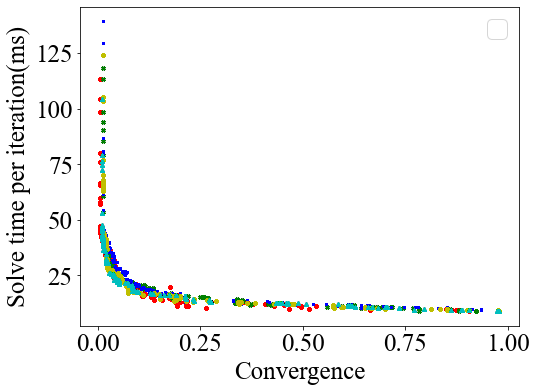

In [253]:
# data is a list of list of tuples: each tuple is (conv, runtime_per_iteration), each list is for a generation, data contains list for 100 generations

# make a plot for each generation and observe the evolution of them
import matplotlib.pyplot as plt

point_colors = ['r', 'g', 'b', 'y', 'c']
point_types = ['o', 'x', 's', 'D', '^']
point_size = 5
gen = [0,1,10,100]
gen = [100]
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 25
# plot dimensions
plt.figure(figsize=(8,6))
for i in gen:
    conv = []
    runtime_per_iteration = []

    for j in range(len(data)):
        conv = [x[0] for x in data[j][i]]
        runtime_per_iteration = [x[1] for x in data[j][i]]

        # scatter plot
        plt.scatter(conv, runtime_per_iteration, c=point_colors[j], marker=point_types[j], s=8)

    plt.xlabel('Convergence')
    plt.ylabel('Solve time per iteration(ms)')
    plt.legend()
    # plot text to times new roman
    
    # save as high-res pdf
    
    #plt.show()

    # avoid clipping of text
    plt.tight_layout()
    plt.savefig(f'generation_{i}.pdf', dpi=300)


        


